In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
from lifelines.utils import survival_table_from_events
from lifelines import KaplanMeierFitter, WeibullAFTFitter, CoxPHFitter
from lifelines.utils import k_fold_cross_validation, concordance_index
from sksurv.metrics import integrated_brier_score
from sksurv.util import Surv

In [2]:
df_gbsg = pd.read_csv("./data/gbsg.csv")
df_pbc = pd.read_csv("./data/pbc.csv")
df_sd = pd.read_csv("./data/simulated_data.csv")

In [3]:
def compute_ibs(cph, df, duration_col, event_col):
    # sksurv structured array
    y = Surv.from_arrays(
        event=df[event_col].astype(bool).values,
        time=df[duration_col].values
    )

    t_min = df[duration_col].min()
    t_max = df[duration_col].max()

    # times must be strictly inside (t_min, t_max) for IPCW estimator
    eps = (t_max - t_min) * 0.001
    times = np.linspace(t_min + eps, t_max - eps, 100)

    # lifelines survival predictions (times x samples)
    surv_df = cph.predict_survival_function(df, times=times)

    # Convert to (samples x times)
    surv_preds = surv_df.T.values

    ibs = integrated_brier_score(
        y,          # training data
        y,          # test data (same here)
        surv_preds,
        times
    )

    return ibs

### GBSG (German Breast Cancer Study Group)

In [4]:
df_gbsg.shape

(686, 12)

In [5]:
df_gbsg.head(10)

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
0,1,132,49,0,18,2,2,0,0,0,1838,0
1,2,1575,55,1,20,3,16,0,0,0,403,1
2,3,1140,56,1,40,3,3,0,0,0,1603,0
3,4,769,45,0,25,3,1,0,4,0,177,0
4,5,130,65,1,30,2,5,0,36,1,1855,0
5,6,1642,48,0,52,2,11,0,0,0,842,1
6,7,475,48,0,21,3,8,0,0,0,293,1
7,8,973,37,0,20,2,9,0,0,1,42,0
8,9,569,67,1,20,2,1,0,0,1,564,1
9,10,1180,45,0,30,2,1,0,0,0,1093,1


In [6]:
df_gbsg = df_gbsg.drop(['pid', 'Unnamed: 0'], axis=1, errors='ignore')

In [7]:
df_gbsg.isna().sum()

age        0
meno       0
size       0
grade      0
nodes      0
pgr        0
er         0
hormon     0
rfstime    0
status     0
dtype: int64

In [8]:
df_gbsg.describe()

,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,53.052478,0.577259,29.329446,2.116618,5.010204,109.995627,96.252187,0.358601,1124.489796,0.435860
std,10.120739,0.494355,14.296217,0.582808,5.475483,202.331552,153.083963,0.479940,642.791948,0.496231
min,21.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,46.000000,0.000000,20.000000,2.000000,1.000000,7.000000,8.000000,0.000000,567.750000,0.000000
50%,53.000000,1.000000,25.000000,2.000000,3.000000,32.500000,36.000000,0.000000,1084.000000,0.000000
75%,61.000000,1.000000,35.000000,2.000000,7.000000,131.750000,114.000000,1.000000,1684.750000,1.000000
max,80.000000,1.000000,120.000000,3.000000,51.000000,2380.000000,1144.000000,1.000000,2659.000000,1.000000


In [9]:
print(df_gbsg["status"].value_counts())

print("\nIn Percentage:")
print(df_gbsg['status'].value_counts(normalize=True))

status
0    387
1    299
Name: count, dtype: int64

In Percentage:
status
0    0.56414
1    0.43586
Name: proportion, dtype: float64


In [10]:
event_rate = df_gbsg["status"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")

Event rate: 0.44
Censoring rate: 0.56


#### GBSG skewness analysis and log transformation

In [11]:
# Identify which continuous covariates are highly skewed
# Only apply log1p to variables with |skewness| > 1
# Use log1p (i.e. log(x+1)) because some variables contain zero values

continuous_cols_gbsg = ['age', 'size', 'nodes', 'pgr', 'er']

print("Skewness of continuous variables:")
print("-" * 45)
for col in continuous_cols_gbsg:
    skew = df_gbsg[col].skew()
    has_zeros = (df_gbsg[col] == 0).sum()
    print(f"  {col:>6s}  skew={skew:+.2f}  min={df_gbsg[col].min():.0f}  zeros={has_zeros}")

# Columns with |skewness| > 1 are candidates for log transformation
# age: ~symmetric (skew ≈ 0), measured in years → NO
# size: moderate skew, tumor size in mm → NO  
# nodes: count data, highly right-skewed, range 1-51 → YES
# pgr: biochemical marker (fmol/l), highly skewed, many zeros → YES
# er: biochemical marker (fmol/l), highly skewed, many zeros → YES

Skewness of continuous variables:
---------------------------------------------
     age  skew=-0.15  min=21  zeros=0
    size  skew=+1.78  min=3  zeros=0
   nodes  skew=+2.88  min=1  zeros=0
     pgr  skew=+4.79  min=0  zeros=88
      er  skew=+3.09  min=0  zeros=82


In [12]:
# Apply log1p ONLY to highly skewed variables (|skewness| > 1)
# nodes, pgr, er are biomarker/count variables with strong right-skew and zero values
df_gbsg['log_nodes'] = np.log1p(df_gbsg['nodes'])
df_gbsg['log_pgr'] = np.log1p(df_gbsg['pgr'])
df_gbsg['log_er'] = np.log1p(df_gbsg['er'])

print("After log1p transformation:")
print("-" * 45)
for raw, logged in [('nodes','log_nodes'), ('pgr','log_pgr'), ('er','log_er')]:
    print(f"  {raw} → {logged}:  skew {df_gbsg[raw].skew():+.2f} → {df_gbsg[logged].skew():+.2f}")

After log1p transformation:
---------------------------------------------
  nodes → log_nodes:  skew +2.88 → +0.59
  pgr → log_pgr:  skew +4.79 → -0.31
  er → log_er:  skew +3.09 → -0.38


#### GBSG scatter plots

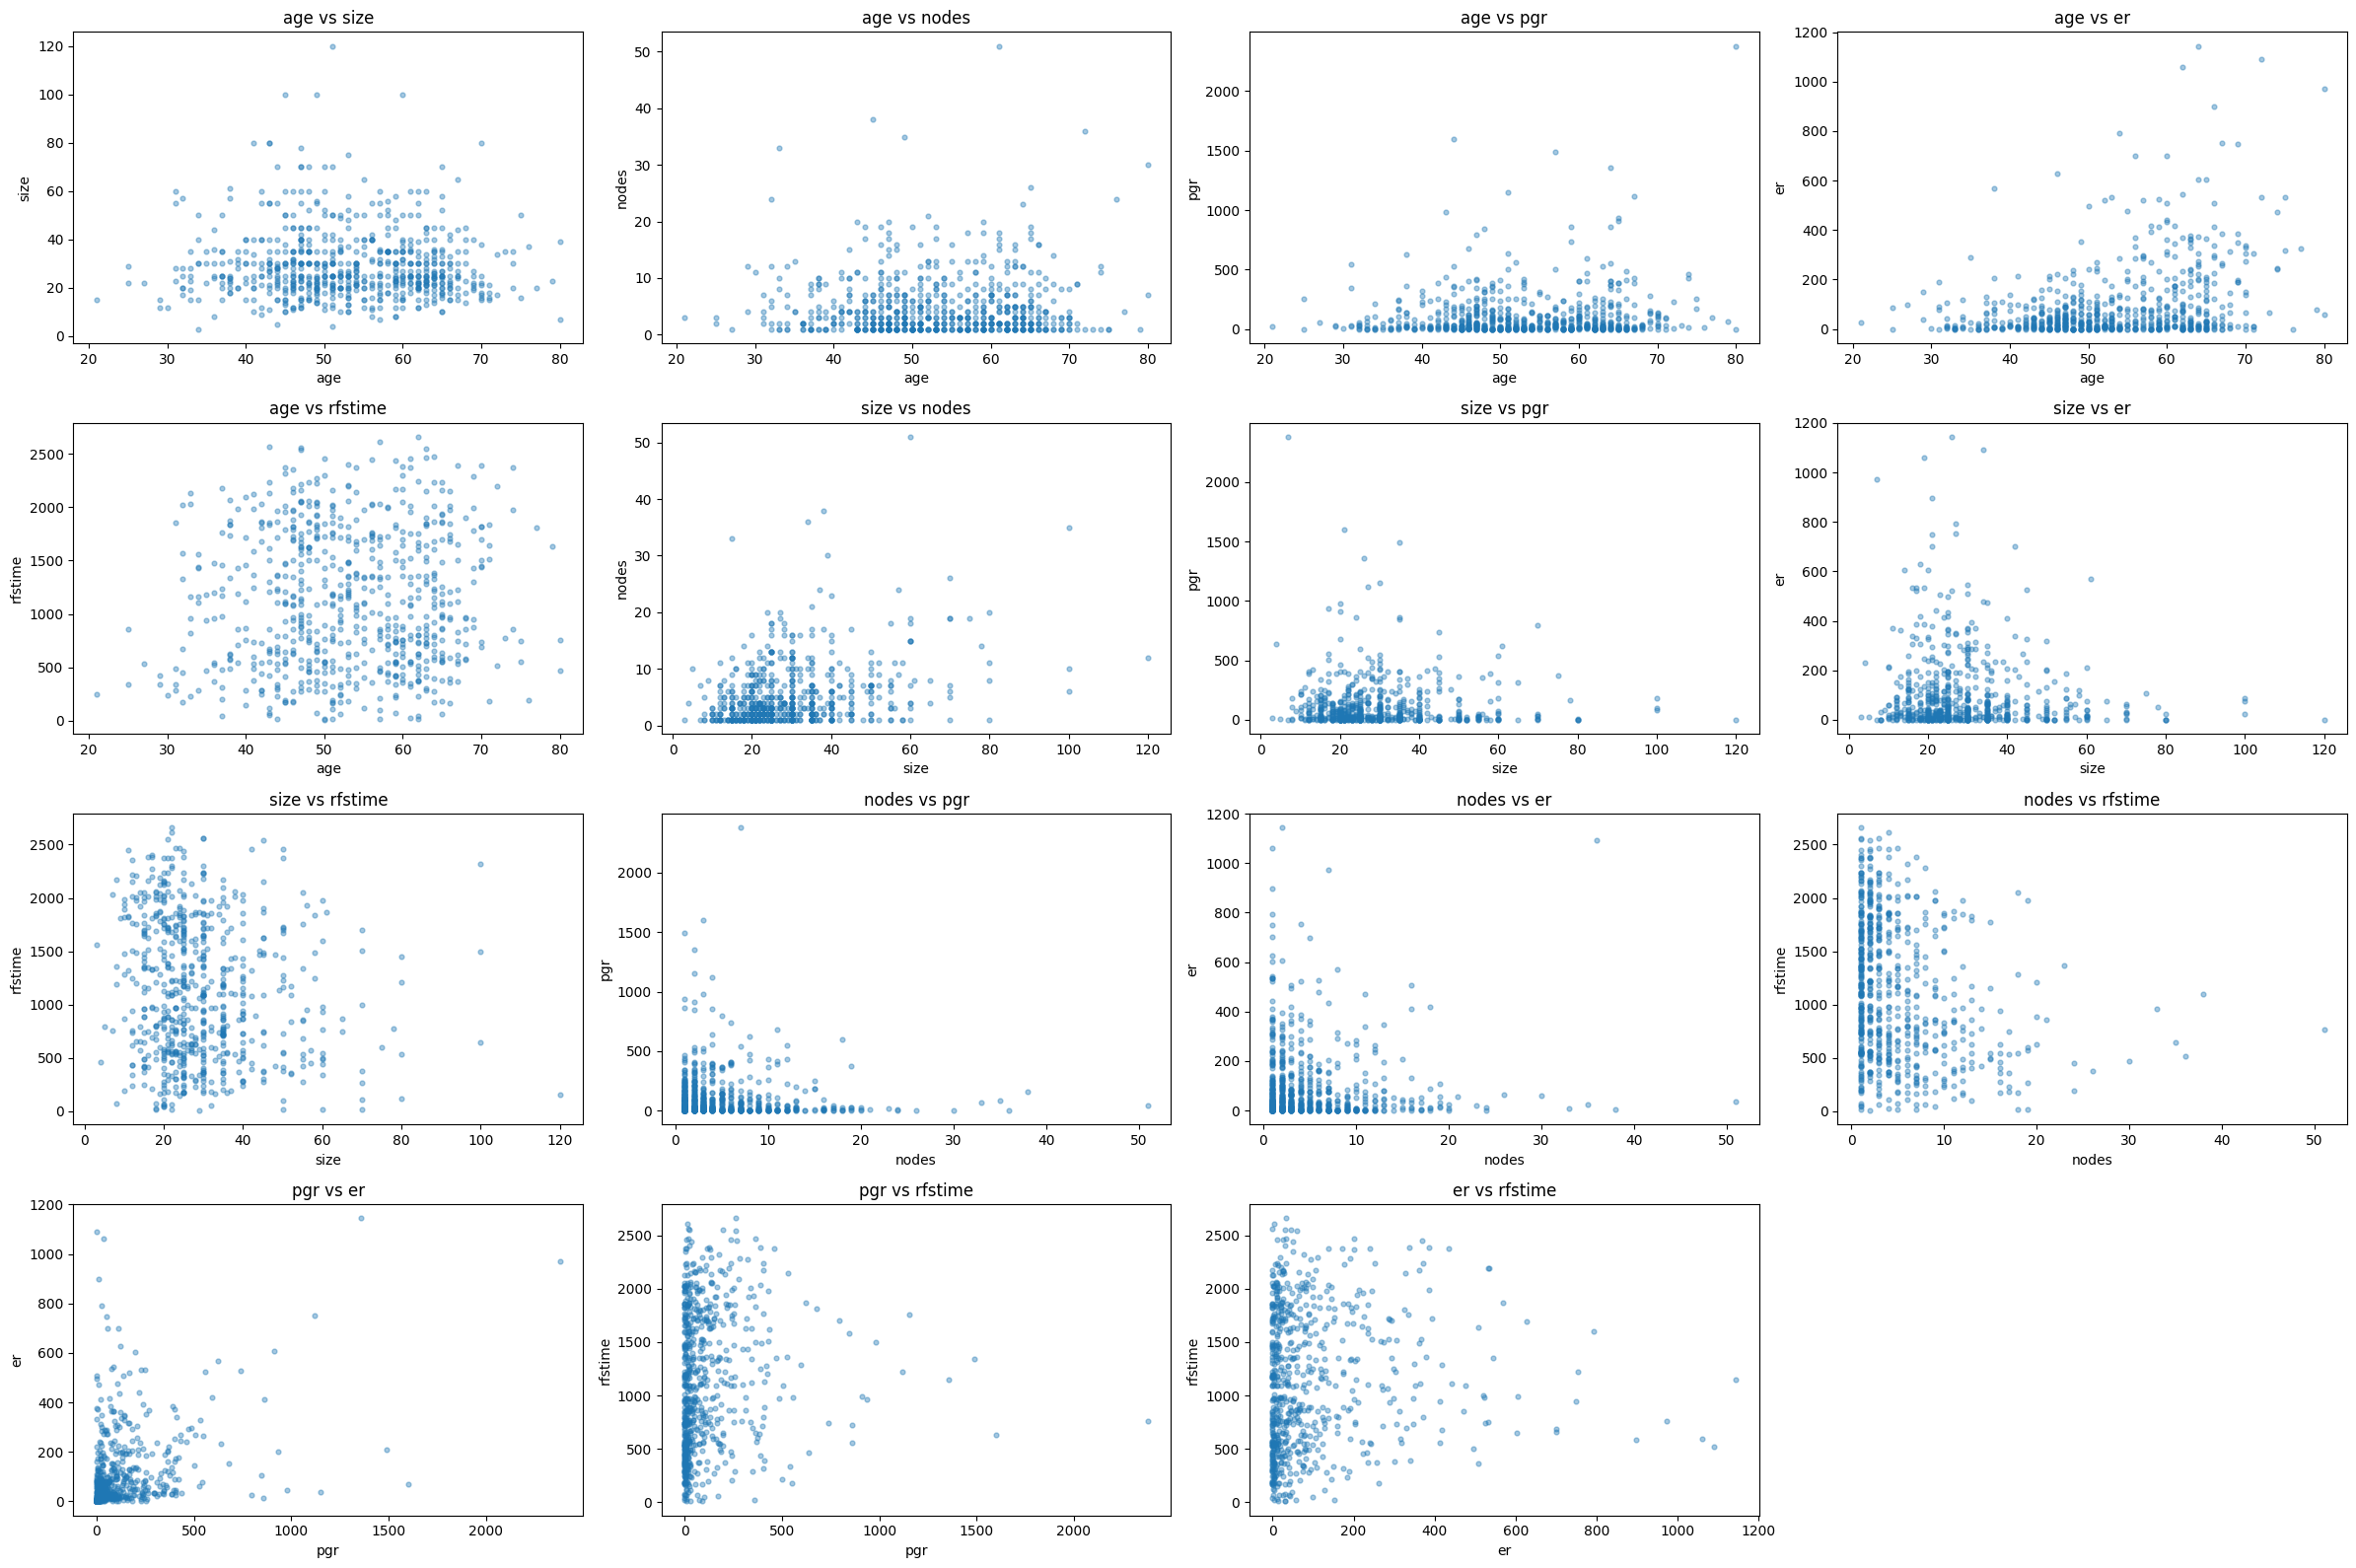

In [13]:
cols = ['age', 'size', 'nodes', 'pgr', 'er', 'rfstime']

pairs = list(itertools.combinations(cols, 2))
n = len(pairs)

cols_grid = 4
rows_grid = math.ceil(n / cols_grid)

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(6*cols_grid, 4*rows_grid))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_gbsg[x], df_gbsg[y], alpha=0.4, s=12)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

for i in range(len(pairs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### GBSG distributions

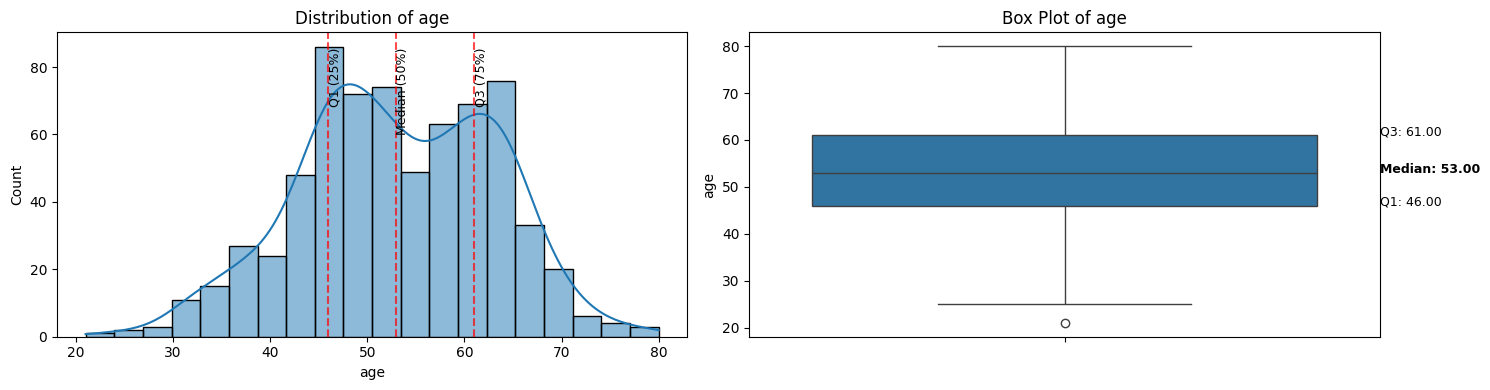

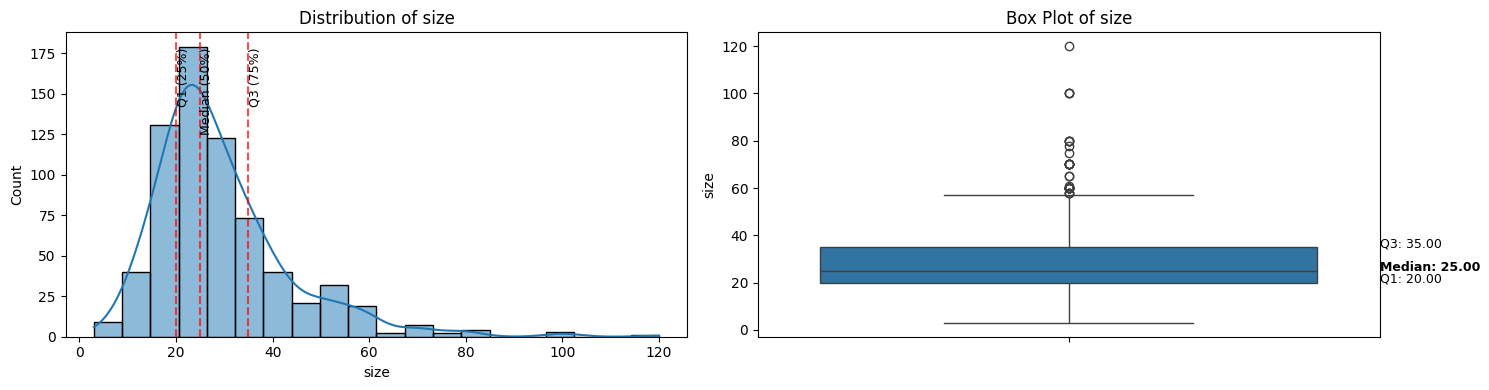

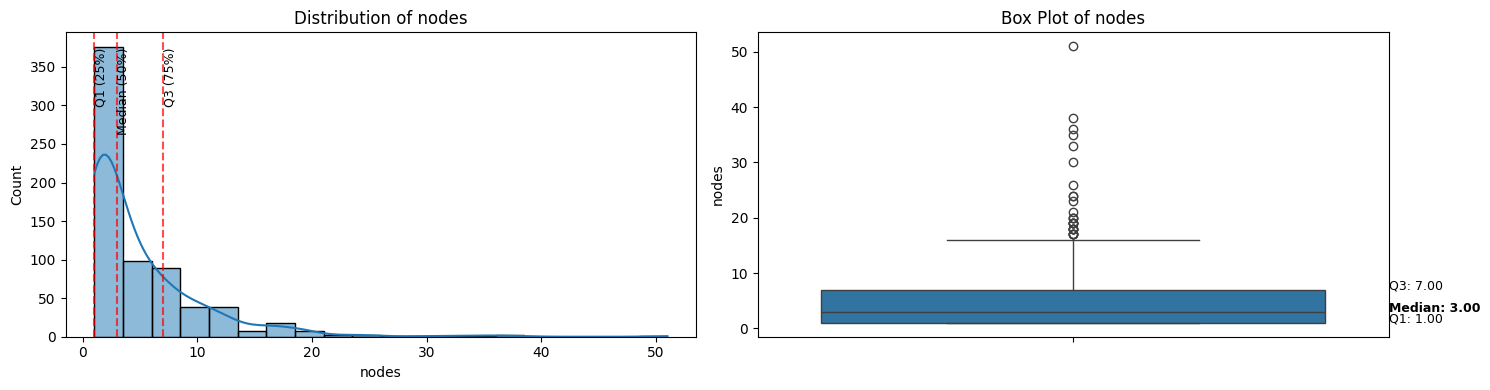

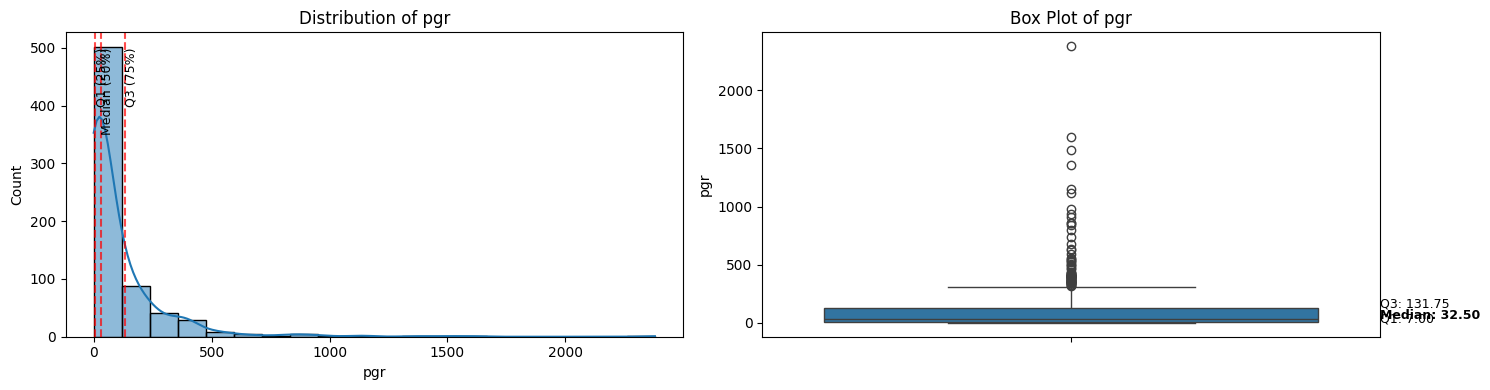

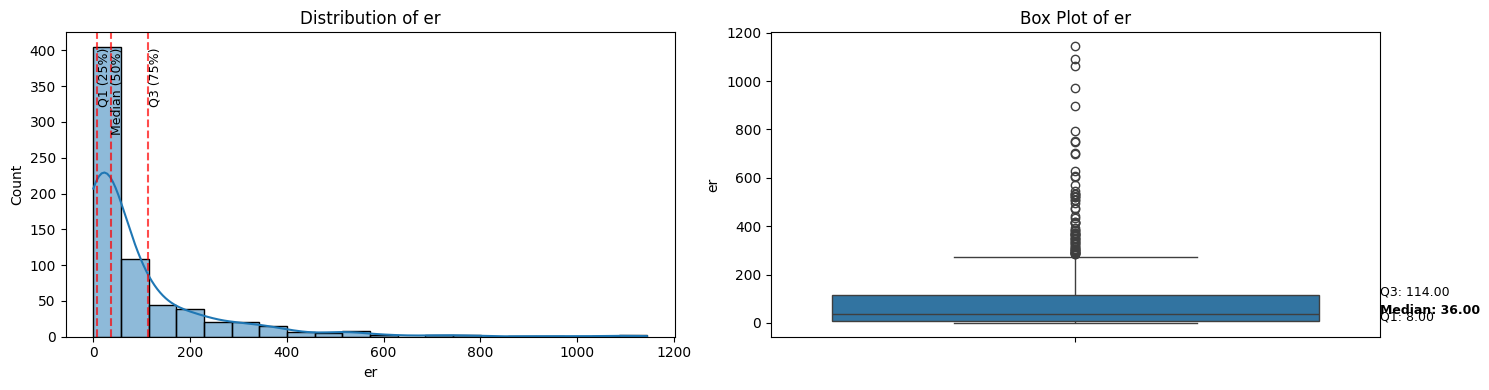

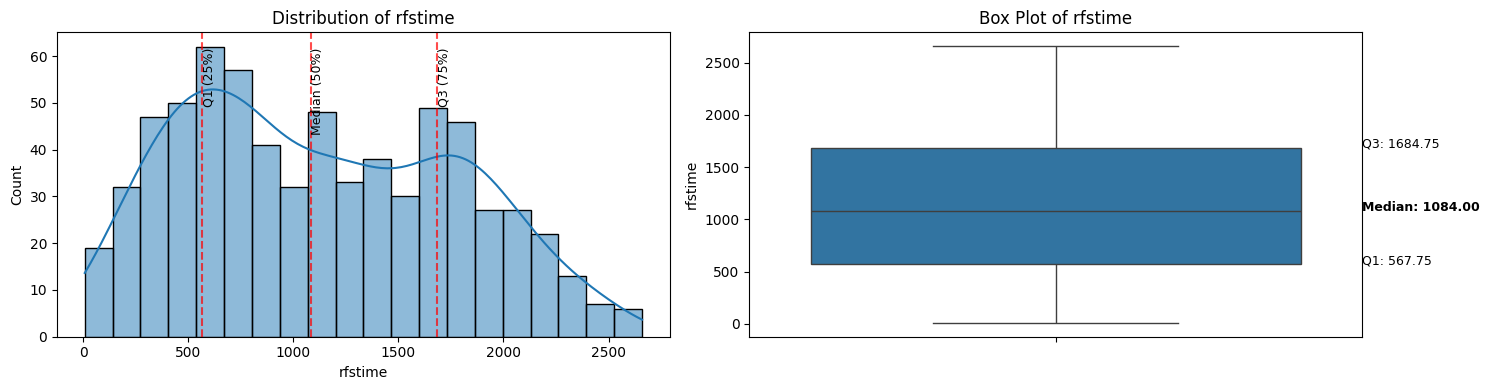

In [14]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    sns.histplot(data=df_gbsg, x=col, kde=True, bins=20, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    quantiles = df_gbsg[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
      
    sns.boxplot(data=df_gbsg, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    q1, median, q3 = df_gbsg[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

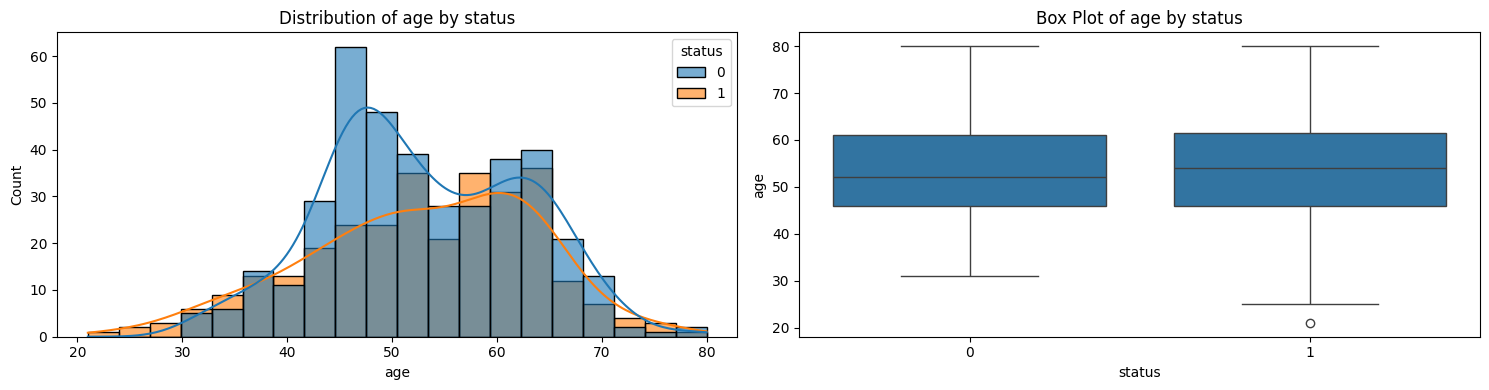

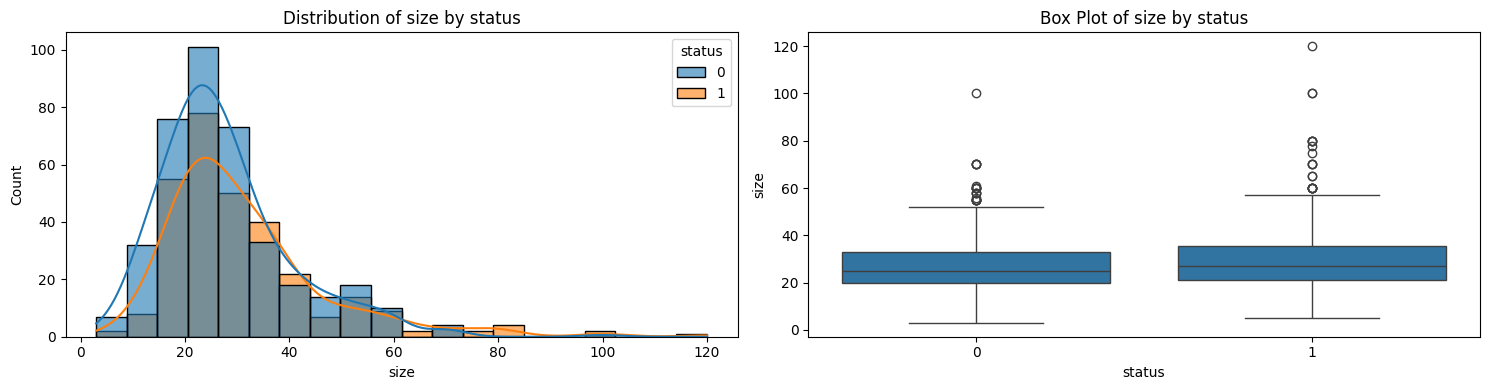

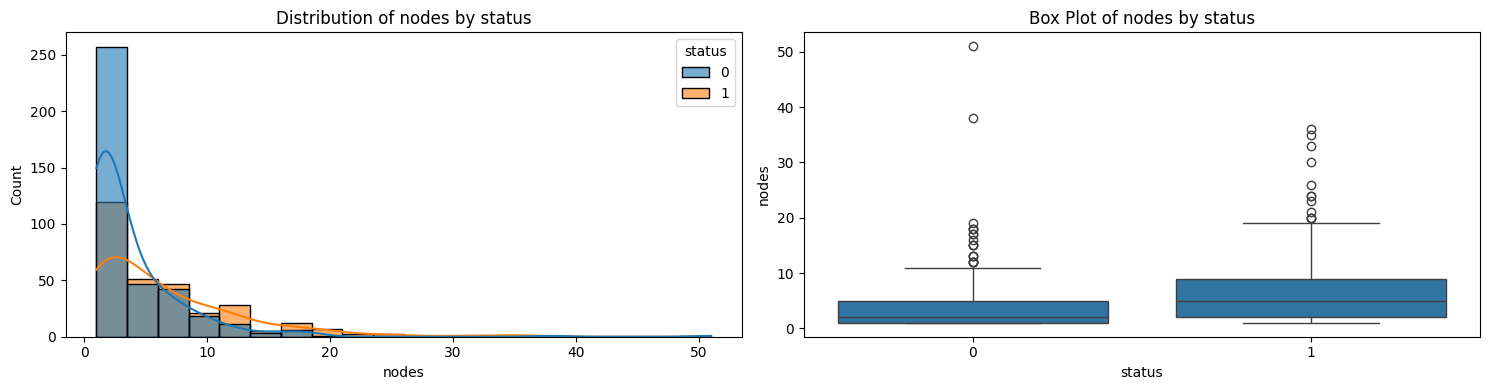

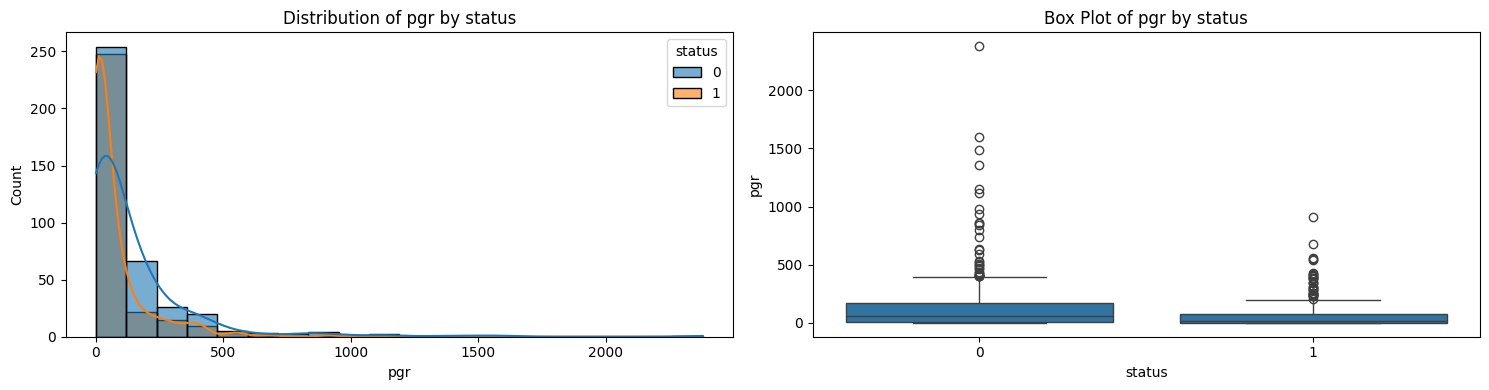

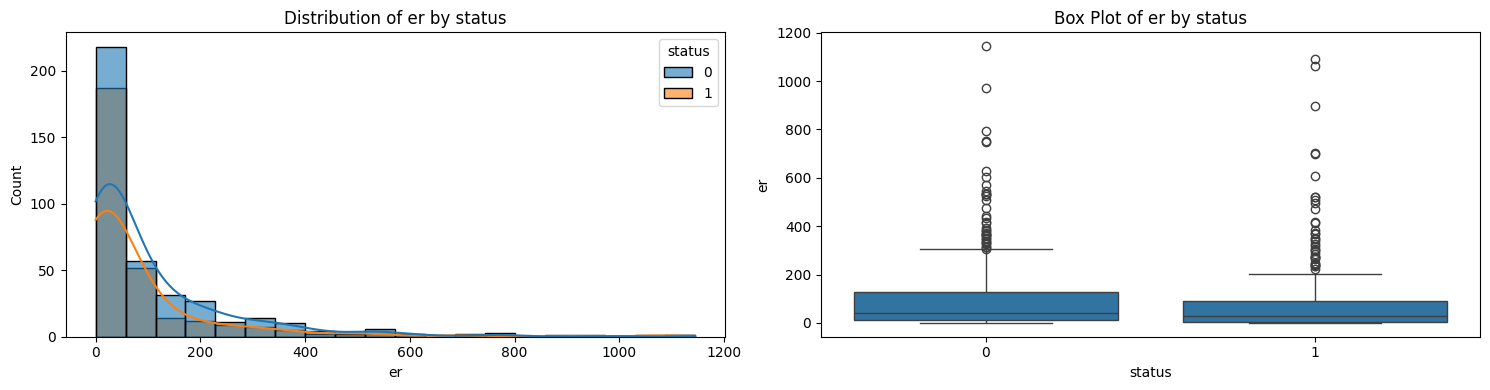

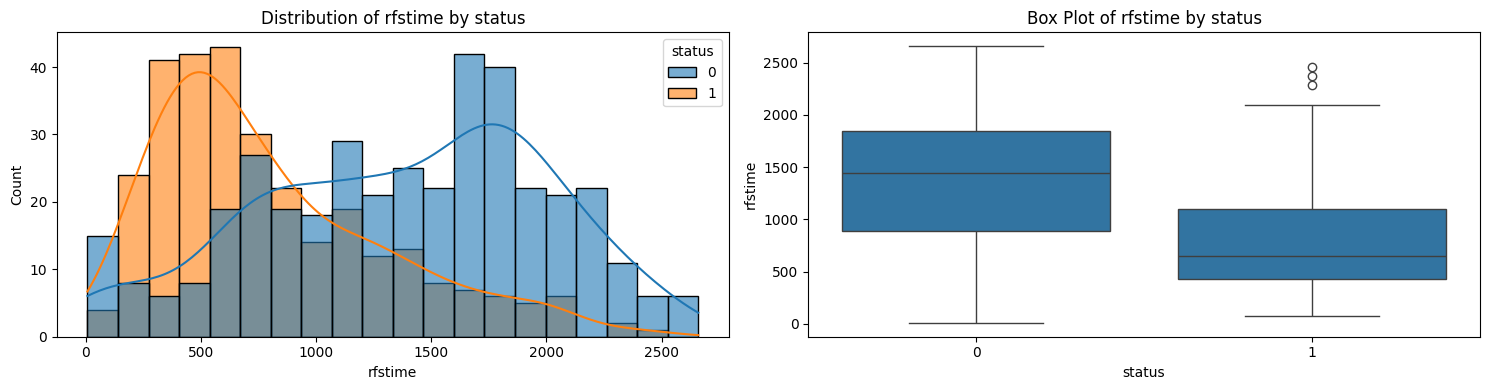

In [15]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    sns.histplot(data=df_gbsg, x=col, hue='status', kde=True, bins=20, alpha=0.6, ax=axes[0])
    axes[0].set_title(f"Distribution of {col} by status")
      
    sns.boxplot(data=df_gbsg, x='status', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by status")
   
    plt.tight_layout()
    plt.show()

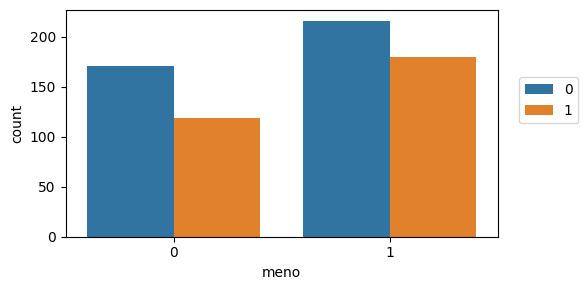

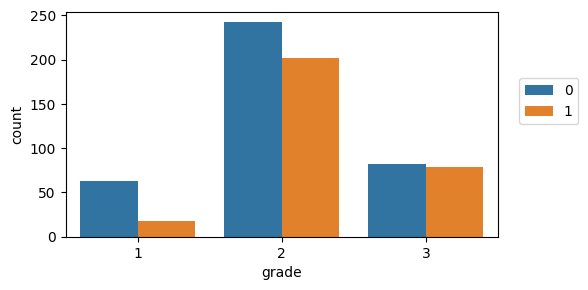

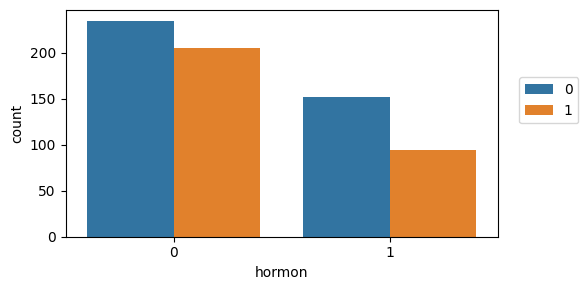

In [16]:
cols_qualitative = ['meno', 'grade', 'hormon']

for col in cols_qualitative: 
    plt.figure(figsize=(6,3), dpi=100) 
    sns.countplot(data=df_gbsg, x=col, hue='status') 
    plt.legend(loc=(1.05,0.5))
    plt.tight_layout()
    plt.show()

#### GBSG correlation

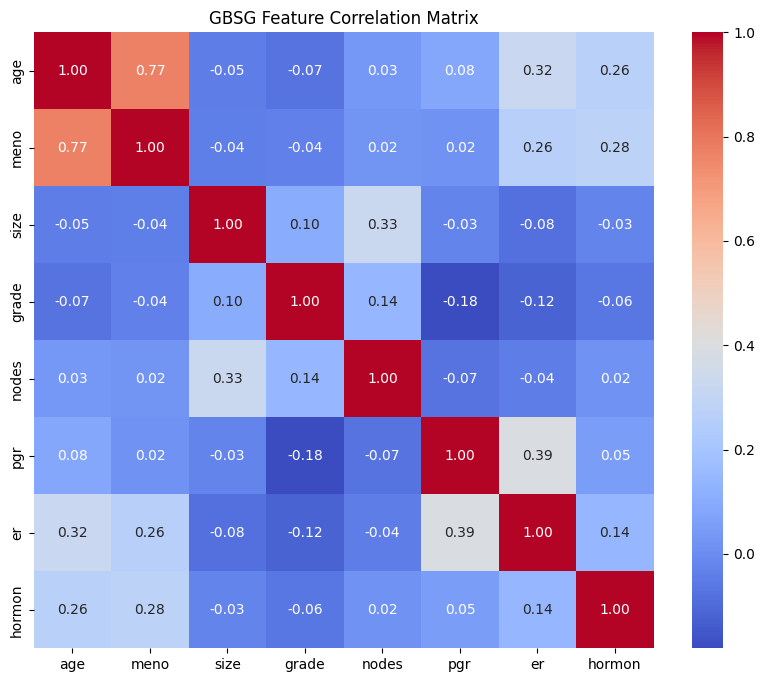

In [17]:
plt.figure(figsize=(10, 8))

# Correlation of original covariates only (exclude log-transformed and outcome columns)
corr = df_gbsg.drop(['rfstime', 'status', 'log_nodes', 'log_pgr', 'log_er'], axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("GBSG Feature Correlation Matrix")
plt.show()

#### GBSG modelling

In [18]:
T = df_gbsg['rfstime']
E = df_gbsg['status']

survival_table_from_events(T, E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,686,686
8.0,1,0,1,0,686
15.0,1,0,1,0,685
16.0,1,0,1,0,684
17.0,2,0,2,0,683
...,...,...,...,...,...
2551.0,1,0,1,0,5
2556.0,1,0,1,0,4
2563.0,1,0,1,0,3


In [19]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 686 total observations, 387 right-censored observations>

In [20]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
8.0,1.000000
15.0,1.000000
16.0,1.000000
17.0,1.000000
...,...
2551.0,0.342758
2556.0,0.342758
2563.0,0.342758


<Axes: xlabel='timeline'>

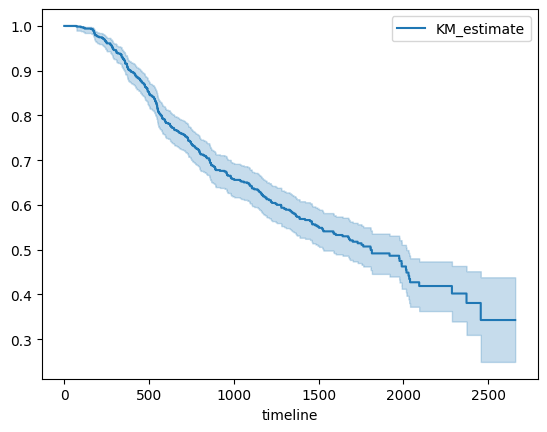

In [21]:
kmf.plot_survival_function()

In [22]:
wft = WeibullAFTFitter()
wft.fit(df_gbsg, duration_col='rfstime', event_col='status')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
   number of observations = 686
number of events observed = 299
           log-likelihood = -2564.27
         time fit was run = 2026-04-01 08:58:32 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age        0.01      1.01      0.01           -0.01            0.02                0.99                1.02
        er        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        grade     -0.13      0.88      0.08           -0.28            0.03                0.76                1.03
        hormon     0.29      1.33      0.09            0.11            0.46                1.11                1.59
        log_er     0.01      1.01      0.04           -0.07            0.09                0.93                1.09
        log_nodes -0.56      0.57      0.13           -0.82           -0.31                0.44                0.73
        log_pgr    0.09      1.10      0.04            0.02            0.17                1.02                1.19
        meno      -0.14      0.87      0.13           -0.40            0.11                0.67                1.11
        nodes      0.01      1.01      0.01           -0.02            0.04                0.98                1.04
        pgr        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        size      -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
        Intercept  8.15   3454.83      0.39            7.38            8.92             1602.23             7449.54
rho_    Intercept  0.35      1.42      0.05            0.26            0.45                1.29                1.56

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00  0.95   0.34      1.55
        er           0.00 -1.31   0.19      2.40
        grade        0.00 -1.59   0.11      3.17
        hormon       0.00  3.16 <0.005      9.29
        log_er       0.00  0.24   0.81      0.30
        log_nodes    0.00 -4.38 <0.005     16.38
        log_pgr      0.00  2.35   0.02      5.73
        meno         0.00 -1.13   0.26      1.96
        nodes        0.00  0.81   0.42      1.27
        pgr          0.00  1.53   0.13      2.99
        size         0.00 -1.12   0.26      1.92
        Intercept    0.00 20.78 <0.005    316.27
rho_    Intercept    0.00  7.27 <0.005     41.38
---
Concordance = 0.70
AIC = 5154.54
log-likelihood ratio test = 146.02 on 11 df
-log2(p) of ll-ratio test = 83.09

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

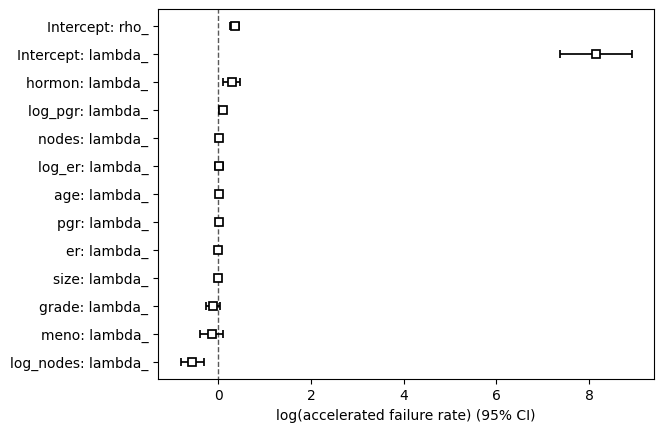

In [23]:
wft.plot()

In [24]:
# Use log-transformed versions for skewed variables; drop raw versions to avoid multicollinearity
# age, meno, size, grade, hormon: kept as-is (not highly skewed or binary/ordinal)
# nodes → log_nodes, pgr → log_pgr, er → log_er (highly skewed biomarkers/counts)
features = ['log_nodes', 'log_pgr', 'log_er', 'age', 'meno', 'size', 'grade', 'hormon', 'rfstime', 'status']

In [25]:
df_gbsg[features].to_csv(r'./data/preprocess-data/preprocess_gbsg.csv')

In [26]:
cph = CoxPHFitter()
cph.fit(df_gbsg[features], duration_col='rfstime', event_col='status', strata=['meno', 'grade', 'hormon'])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
                   strata = ['meno', 'grade', 'hormon']
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1118.90
         time fit was run = 2026-04-01 08:58:34 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
log_nodes  0.59      1.80      0.08            0.42            0.75                1.52                2.12
log_pgr   -0.19      0.83      0.04           -0.27           -0.11                0.76                0.90
log_er     0.03      1.03      0.04           -0.06            0.11                0.95                1.12
age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
size       0.01      1.01      0.00           -0.00            0.01                1.00                1.01

           cmp to     z      p  -log2(p)
covariate                               
log_nodes    0.00  6.99 <0.005     38.45
log_pgr      0.00 -4.55 <0.005     17.51
log_er       0.00  0.68   0.50      1.01
age          0.00 -0.82   0.41      1.29
size         0.00  1.33   0.18      2.45
---
Concordance = 0.67
Partial AIC = 2247.80
log-likelihood ratio test = 95.54 on 5 df
-log2(p) of ll-ratio test = 60.92


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
                test_statistic      p  -log2(p)
age       km              2.41   0.12      3.05
          rank            9.73 <0.005      9.11
log_er    km              2.07   0.15      2.74
          rank            0.31   0.58      0.80
log_nodes km              0.57   0.45      1.15
          rank            0.32   0.57      0.81
log_pgr   km              0.09   0.76      0.40
          rank            0.32   0.57      0.81
size      km              0.03   0.85      0.23
          rank            0.04   0.85      0.24



1. Variable 'age' failed the non-proportional test: p-value is 0.0018.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Propor

[[<Axes: xlabel='rank-transformed time\n(p=0.5707)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4514)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5694)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7592)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5763)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1500)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0018)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1204)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8494)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8516)'>]]

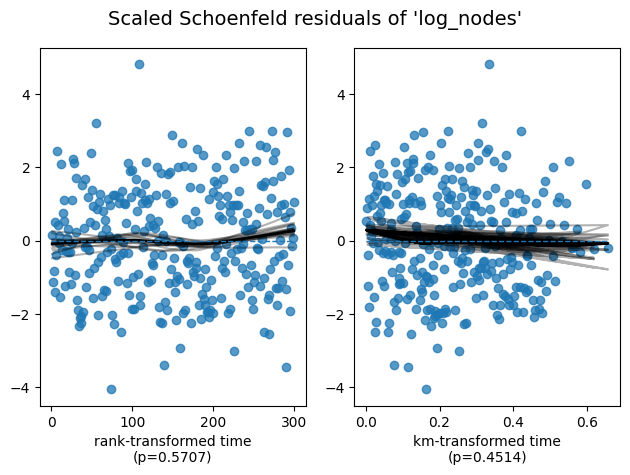

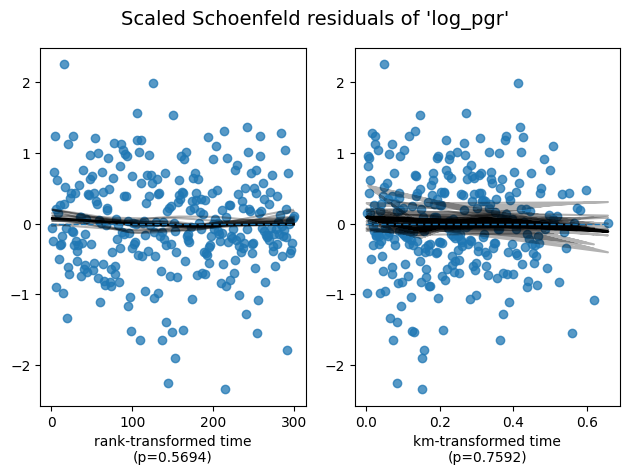

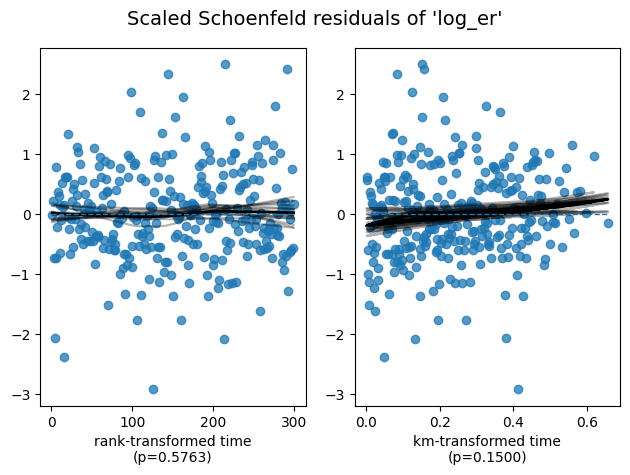

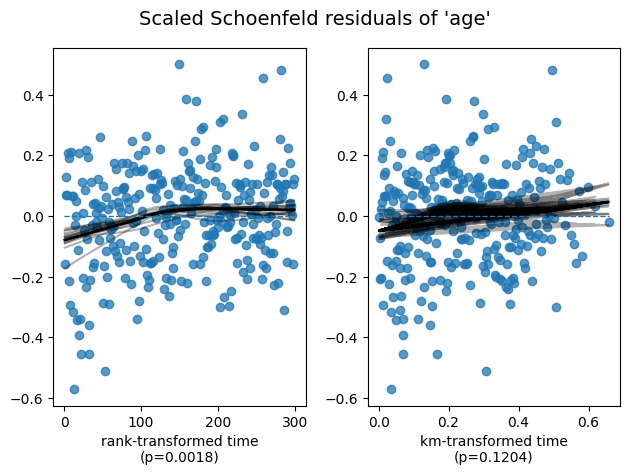

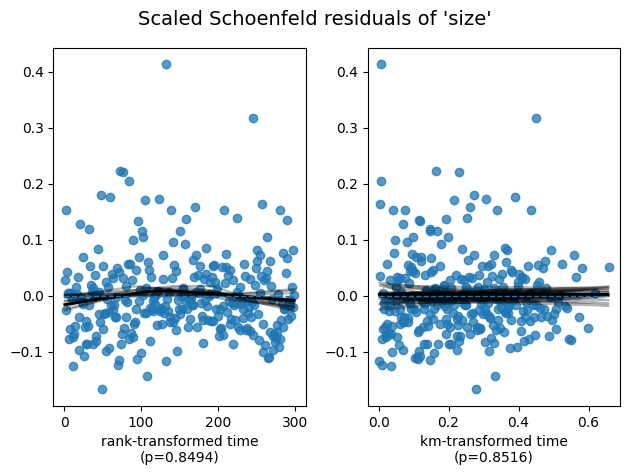

In [27]:
cph.check_assumptions(df_gbsg[features], show_plots=True, p_value_threshold=0.05)

In [28]:
scores = k_fold_cross_validation(
    cph, df_gbsg[features], duration_col='rfstime', event_col='status', k=5,
    scoring_method='concordance_index'
)

print("Average C-index:", np.mean(scores))

c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index i

Average C-index: 0.6800544638918493


c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


In [29]:
pred = cph.predict_partial_hazard(df_gbsg)
c_index_gbsg = concordance_index(df_gbsg["rfstime"], -pred, df_gbsg["status"])
print("CoxPH C-index:", c_index_gbsg)

CoxPH C-index: 0.6872069255741253


In [30]:
ibs_gbsg = compute_ibs(
    cph=cph,
    df=df_gbsg,
    duration_col="rfstime",
    event_col="status"
)

print("CoxPH IBS:", ibs_gbsg)

CoxPH IBS: 0.23075725138453795


In [31]:
print("AIC:", cph.AIC_partial_)

AIC: 1683.9809059548693


In [32]:
log_likelihood = cph.log_likelihood_
k = len(cph.params_)
n = cph._n_examples

bic = -2 * log_likelihood + k * np.log(n)

print("BIC:", bic)

BIC: 1705.521398162417


### PBC (Primary Biliary Cholangitis) - Mayo Clinic

In [33]:
df_pbc.shape

(418, 20)

In [34]:
df_pbc.head(10)

,id,time,status,trt,age,sex,ascites,hepato,spiders,edema,bili,chol,albumin,copper,alk.phos,ast,trig,platelet,protime,stage
0,1,400,2,1.0,58.765229,f,1.0,1.0,1.0,1.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0,1.0,56.446270,f,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2,1.0,70.072553,m,0.0,0.0,0.0,0.5,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2,1.0,54.740589,f,0.0,1.0,1.0,0.5,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1,2.0,38.105407,f,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,2,2.0,66.258727,f,0.0,1.0,0.0,0.0,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,0,2.0,55.534565,f,0.0,1.0,0.0,0.0,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,2,2.0,53.056810,f,0.0,0.0,0.0,0.0,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,2,1.0,42.507871,f,0.0,0.0,1.0,0.0,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,2,2.0,70.559890,f,1.0,0.0,1.0,1.0,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


In [35]:
df_pbc.columns.tolist()

['id',
 'time',
 'status',
 'trt',
 'age',
 'sex',
 'ascites',
 'hepato',
 'spiders',
 'edema',
 'bili',
 'chol',
 'albumin',
 'copper',
 'alk.phos',
 'ast',
 'trig',
 'platelet',
 'protime',
 'stage']

In [36]:
df_pbc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        418 non-null    int64  
 1   time      418 non-null    int64  
 2   status    418 non-null    int64  
 3   trt       312 non-null    float64
 4   age       418 non-null    float64
 5   sex       418 non-null    object 
 6   ascites   312 non-null    float64
 7   hepato    312 non-null    float64
 8   spiders   312 non-null    float64
 9   edema     418 non-null    float64
 10  bili      418 non-null    float64
 11  chol      284 non-null    float64
 12  albumin   418 non-null    float64
 13  copper    310 non-null    float64
 14  alk.phos  312 non-null    float64
 15  ast       312 non-null    float64
 16  trig      282 non-null    float64
 17  platelet  407 non-null    float64
 18  protime   416 non-null    float64
 19  stage     412 non-null    float64
dtypes: float64(16), int64(3), object

In [37]:
df_pbc.isna().sum()

id            0
time          0
status        0
trt         106
age           0
sex           0
ascites     106
hepato      106
spiders     106
edema         0
bili          0
chol        134
albumin       0
copper      108
alk.phos    106
ast         106
trig        136
platelet     11
protime       2
stage         6
dtype: int64

#### PBC data preprocessing

In [38]:
# Drop id column (not a prognostic variable)
df_pbc = df_pbc.drop('id', axis=1, errors='ignore')

# Dataset: R survival::pbc (Kaggle jixing475)
# Columns: time, status, trt, age, sex, ascites, hepato, spiders, edema,
#           bili, chol, albumin, copper, alk.phos, ast, trig, platelet, protime, stage

# status: 0=censored, 1=transplant, 2=dead
# For Cox PH: treat death (2) as the event, censor everything else
df_pbc['status_binary'] = (df_pbc['status'] == 2).astype(int)

# trt: 1=D-penicillamine, 2=placebo, NaN=not randomised
df_pbc['trt'] = df_pbc['trt'].fillna(0).astype(int)

# sex: m/f string in R export → convert to binary (0=male, 1=female)
if df_pbc['sex'].dtype == 'object':
    df_pbc['sex'] = (df_pbc['sex'].str.lower() == 'f').astype(int)

# stage: convert to int (may have NaN)
# Will be handled in missing value imputation

print("Original status distribution:")
print(df_pbc['status'].value_counts().sort_index())
print("\nBinary status (0=censored/transplant, 1=dead):")
print(df_pbc['status_binary'].value_counts().sort_index())

Original status distribution:
status
0    232
1     25
2    161
Name: count, dtype: int64

Binary status (0=censored/transplant, 1=dead):
status_binary
0    257
1    161
Name: count, dtype: int64


In [39]:
# Handle missing values
print("Missing values:")
missing = df_pbc.isna().sum()
print(missing[missing > 0])

# Impute continuous variables with median (appropriate for skewed clinical data)
cols_to_impute = df_pbc.columns[df_pbc.isna().any()].tolist()
for col in cols_to_impute:
    if df_pbc[col].dtype in ['float64', 'int64', 'Float64']:
        median_val = df_pbc[col].median()
        n_missing = df_pbc[col].isna().sum()
        df_pbc[col] = df_pbc[col].fillna(median_val)
        print(f"  {col}: imputed {n_missing} missing with median={median_val:.2f}")

# stage: drop rows if missing (categorical, can't impute meaningfully)
if 'stage' in cols_to_impute and df_pbc['stage'].isna().sum() > 0:
    df_pbc = df_pbc.dropna(subset=['stage'])
    df_pbc['stage'] = df_pbc['stage'].astype(int)

print(f"\nFinal shape: {df_pbc.shape}")
print(f"Total remaining missing: {df_pbc.isna().sum().sum()}")

Missing values:
ascites     106
hepato      106
spiders     106
chol        134
copper      108
alk.phos    106
ast         106
trig        136
platelet     11
protime       2
stage         6
dtype: int64
  ascites: imputed 106 missing with median=0.00
  hepato: imputed 106 missing with median=1.00
  spiders: imputed 106 missing with median=0.00
  chol: imputed 134 missing with median=309.50
  copper: imputed 108 missing with median=73.00
  alk.phos: imputed 106 missing with median=1259.00
  ast: imputed 106 missing with median=114.70
  trig: imputed 136 missing with median=108.00
  platelet: imputed 11 missing with median=251.00
  protime: imputed 2 missing with median=10.60
  stage: imputed 6 missing with median=3.00

Final shape: (418, 20)
Total remaining missing: 0


In [40]:
print(df_pbc["status_binary"].value_counts())

print("\nIn Percentage:")
print(df_pbc['status_binary'].value_counts(normalize=True))

status_binary
0    257
1    161
Name: count, dtype: int64

In Percentage:
status_binary
0    0.614833
1    0.385167
Name: proportion, dtype: float64


In [41]:
event_rate = df_pbc["status_binary"].mean()
censor_rate = 1 - event_rate

print(f"Event rate (death): {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")

Event rate (death): 0.39
Censoring rate: 0.61


In [42]:
df_pbc.describe()

,time,status,trt,age,sex,ascites,hepato,spiders,edema,bili,chol,albumin,copper,alk.phos,ast,trig,platelet,protime,stage,status_binary
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1917.782297,0.830144,1.114833,50.741551,0.894737,0.057416,0.636364,0.215311,0.100478,3.220813,350.272727,3.497440,91.279904,1799.144976,120.564067,119.267943,256.866029,10.731100,3.023923,0.385167
std,1104.672992,0.955785,0.781206,10.447214,0.307260,0.232915,0.481622,0.411530,0.253417,4.407506,193.123893,0.424972,74.485481,1875.121982,49.085094,54.050691,97.024861,1.019587,0.875678,0.487218
min,41.000000,0.000000,0.000000,26.277892,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000,0.000000
25%,1092.750000,0.000000,0.000000,42.832307,1.000000,0.000000,0.000000,0.000000,0.000000,0.800000,273.000000,3.242500,51.250000,1016.250000,91.000000,95.000000,190.000000,10.000000,2.000000,0.000000
50%,1730.000000,0.000000,1.000000,51.000684,1.000000,0.000000,1.000000,0.000000,0.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000,0.000000
75%,2613.500000,2.000000,2.000000,58.240931,1.000000,0.000000,1.000000,0.000000,0.000000,3.400000,347.750000,3.770000,100.750000,1707.750000,135.750000,127.750000,315.500000,11.100000,4.000000,1.000000
max,4795.000000,2.000000,2.000000,78.439425,1.000000,1.000000,1.000000,1.000000,1.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000,1.000000


#### PBC skewness analysis and log transformation

In [43]:
# Identify continuous covariates and check skewness
# PBC dataset (R survival::pbc export from Kaggle jixing475) column units:
#   age       - age in years
#   bili      - serum bilirubin (mg/dl)
#   chol      - serum cholesterol (mg/dl)
#   albumin   - serum albumin (g/dl)
#   copper    - urine copper (ug/day)
#   alk.phos  - alkaline phosphatase (U/liter)
#   ast       - aspartate aminotransferase, formerly SGOT (U/ml)
#   trig      - triglycerides (mg/dl)
#   platelet  - platelet count (per cubic ml/1000)
#   protime   - standardised blood clotting time (seconds)

continuous_cols_pbc = ['age', 'bili', 'chol', 'albumin', 'copper', 'alk.phos', 'ast', 'trig', 'platelet', 'protime']

print("Skewness of PBC continuous variables:")
print("-" * 60)
for col in continuous_cols_pbc:
    if col in df_pbc.columns:
        skew = df_pbc[col].skew()
        has_zeros = (df_pbc[col] == 0).sum()
        flag = " ← HIGHLY SKEWED" if abs(skew) > 1 else ""
        print(f"  {col:>12s}  skew={skew:+.2f}  min={df_pbc[col].min():.1f}  zeros={has_zeros}{flag}")
    else:
        print(f"  {col:>12s}  ** COLUMN NOT FOUND **")

Skewness of PBC continuous variables:
------------------------------------------------------------
           age  skew=+0.09  min=26.3  zeros=0
          bili  skew=+2.72  min=0.3  zeros=0 ← HIGHLY SKEWED
          chol  skew=+4.29  min=120.0  zeros=0 ← HIGHLY SKEWED
       albumin  skew=-0.47  min=2.0  zeros=0
        copper  skew=+2.84  min=4.0  zeros=0 ← HIGHLY SKEWED
      alk.phos  skew=+3.60  min=289.0  zeros=0 ← HIGHLY SKEWED
           ast  skew=+1.78  min=26.4  zeros=0 ← HIGHLY SKEWED
          trig  skew=+3.27  min=33.0  zeros=0 ← HIGHLY SKEWED
      platelet  skew=+0.64  min=62.0  zeros=0
       protime  skew=+2.23  min=9.0  zeros=0 ← HIGHLY SKEWED


In [44]:
# Apply log1p ONLY to highly skewed variables (|skewness| > 1)
# These are typically biomarker concentrations with right-skewed distributions
# Use log1p = log(x+1) to handle any zero values safely

skewed_cols = {}
for col in continuous_cols_pbc:
    if col in df_pbc.columns and abs(df_pbc[col].skew()) > 1:
        log_name = 'log_' + col.replace('.', '_')
        df_pbc[log_name] = np.log1p(df_pbc[col])
        skewed_cols[col] = log_name

print("Log1p transformations applied:")
print("-" * 60)
for raw, logged in skewed_cols.items():
    print(f"  {raw:>12s} → {logged}:  skew {df_pbc[raw].skew():+.2f} → {df_pbc[logged].skew():+.2f}")

print(f"\nVariables NOT transformed (approximately symmetric, |skew| <= 1):")
for col in continuous_cols_pbc:
    if col not in skewed_cols and col in df_pbc.columns:
        print(f"  {col:>12s}  skew={df_pbc[col].skew():+.2f}")

Log1p transformations applied:
------------------------------------------------------------
          bili → log_bili:  skew +2.72 → +1.14
          chol → log_chol:  skew +4.29 → +1.60
        copper → log_copper:  skew +2.84 → -0.19
      alk.phos → log_alk_phos:  skew +3.60 → +1.21
           ast → log_ast:  skew +1.78 → -0.14
          trig → log_trig:  skew +3.27 → +0.54
       protime → log_protime:  skew +2.23 → +1.56

Variables NOT transformed (approximately symmetric, |skew| <= 1):
           age  skew=+0.09
       albumin  skew=-0.47
      platelet  skew=+0.64


#### PBC continuous variable distributions

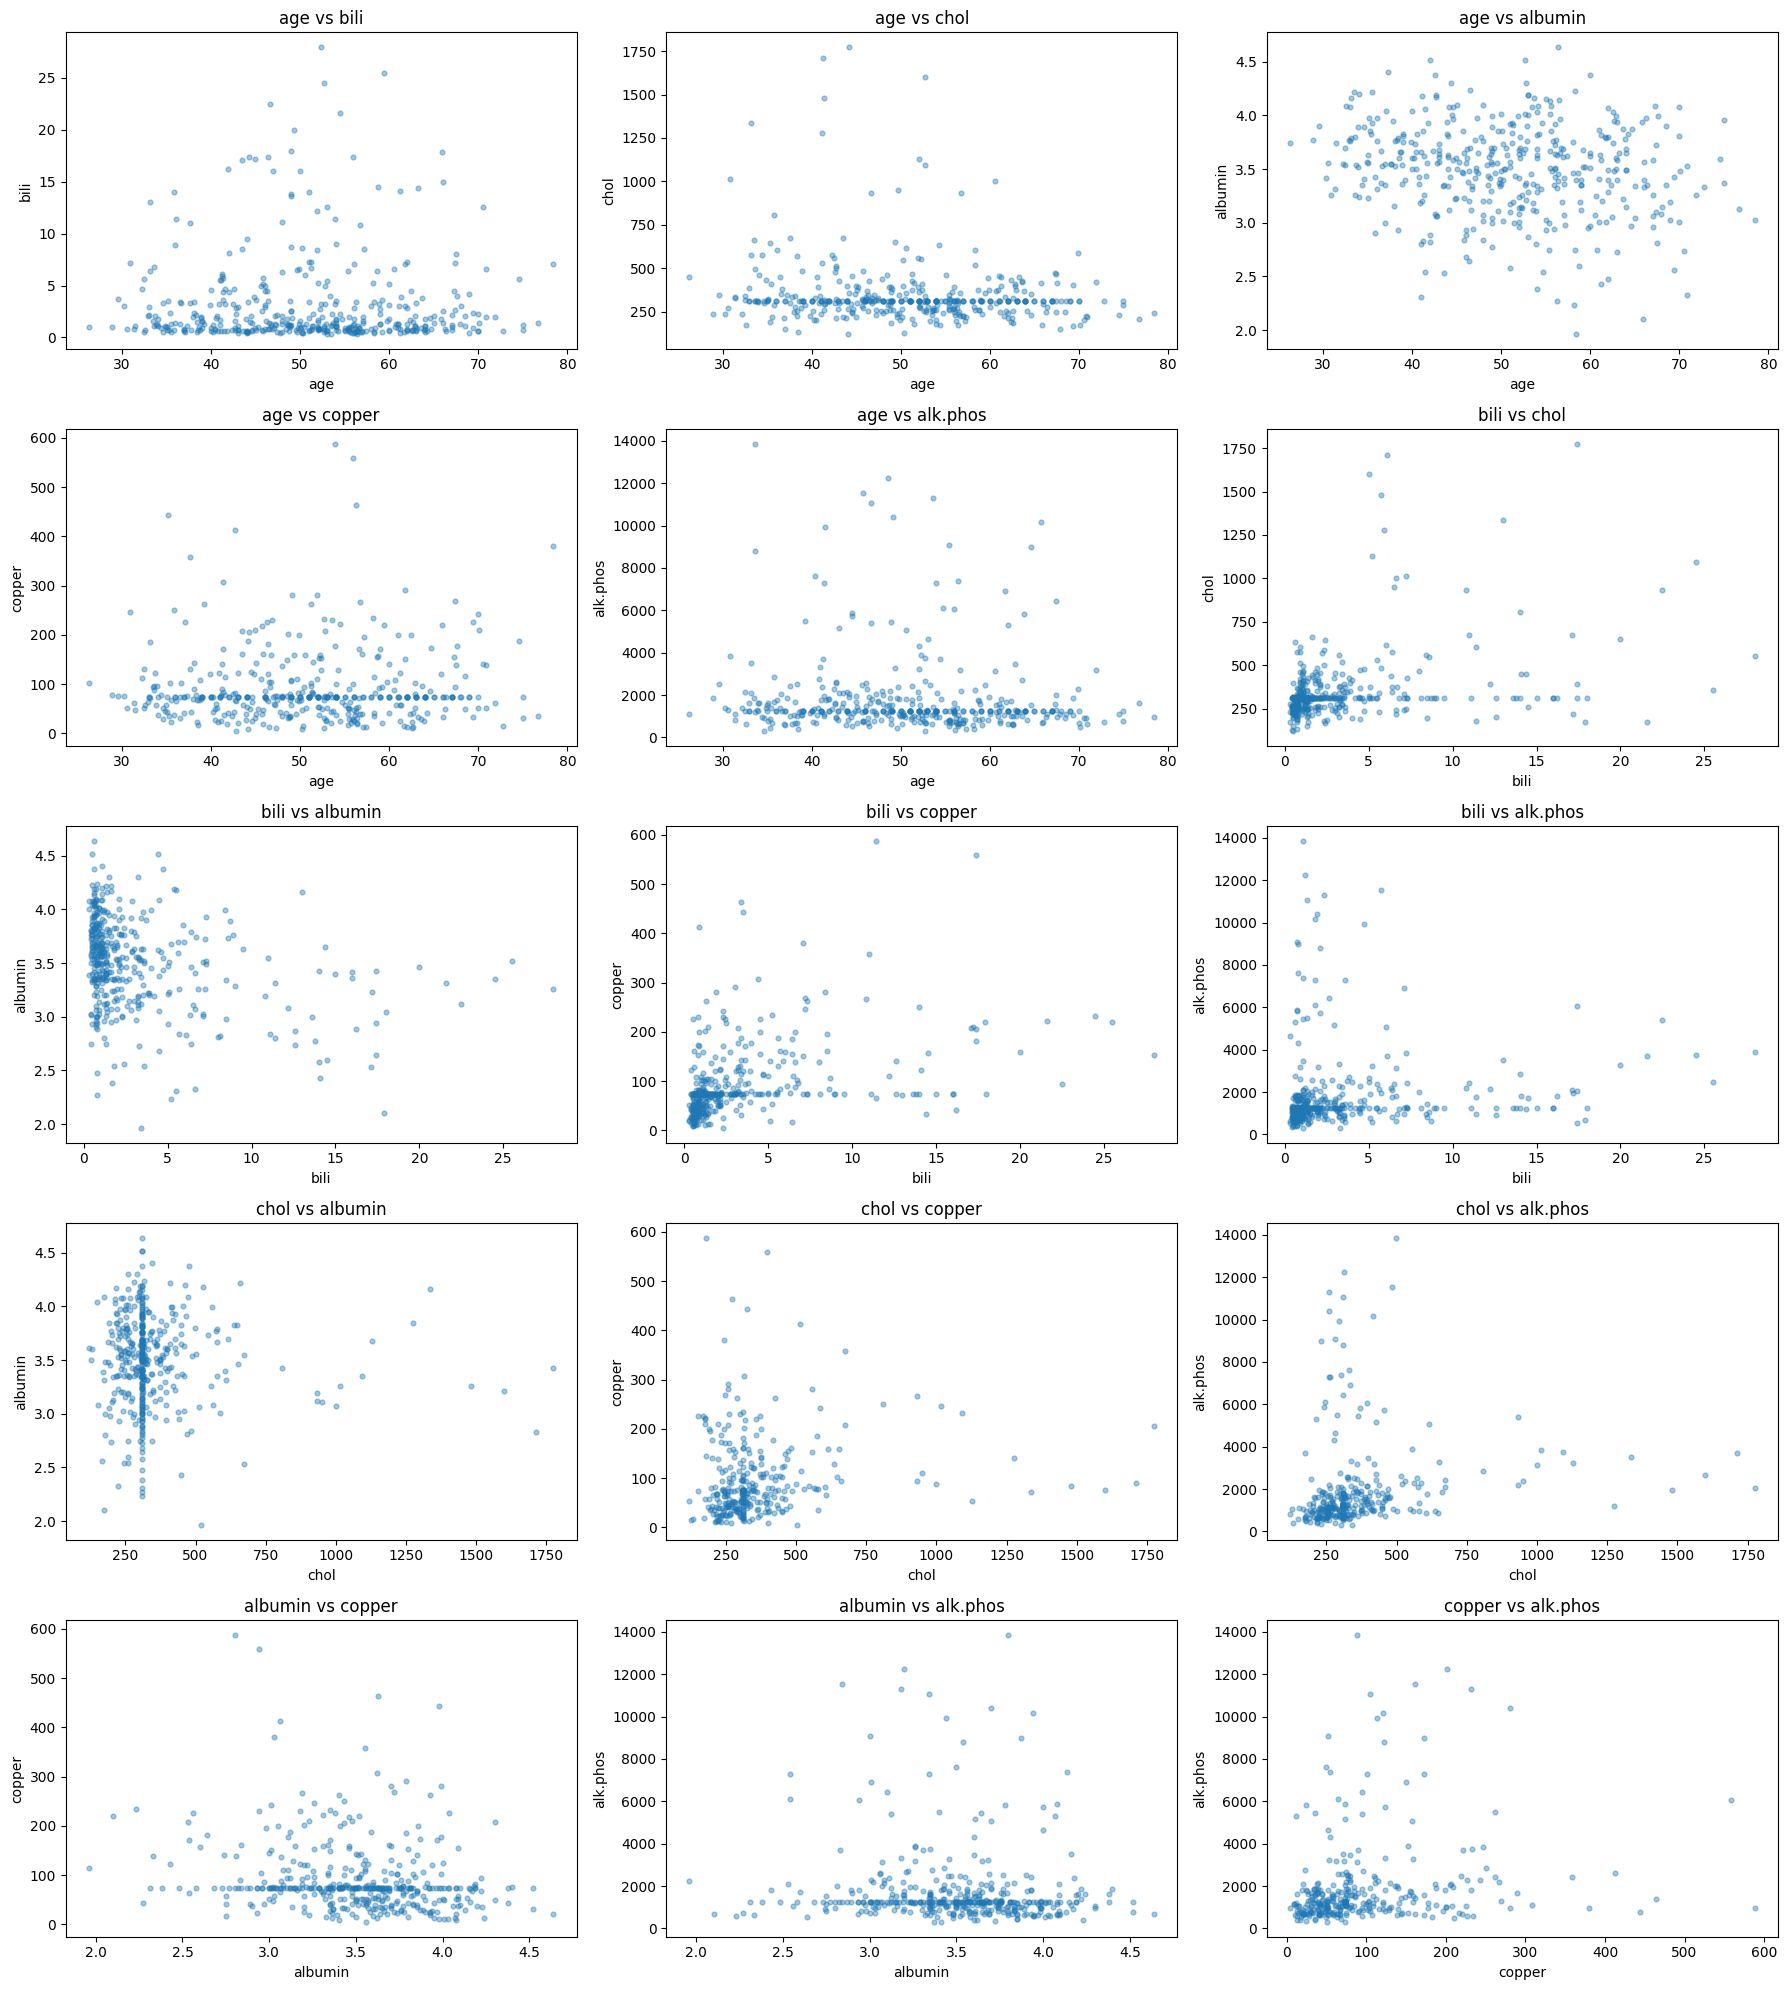

In [45]:
cols_pbc_continuous = ['age', 'bili', 'chol', 'albumin', 'copper', 'alk.phos', 'ast', 'trig', 'platelet', 'protime', 'time']

pairs = list(itertools.combinations(cols_pbc_continuous[:6], 2))
n = len(pairs)
cols_grid = 3
rows_grid = math.ceil(n / cols_grid)

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(6*cols_grid, 4*rows_grid))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_pbc[x], df_pbc[y], alpha=0.4, s=12)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

for i in range(len(pairs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

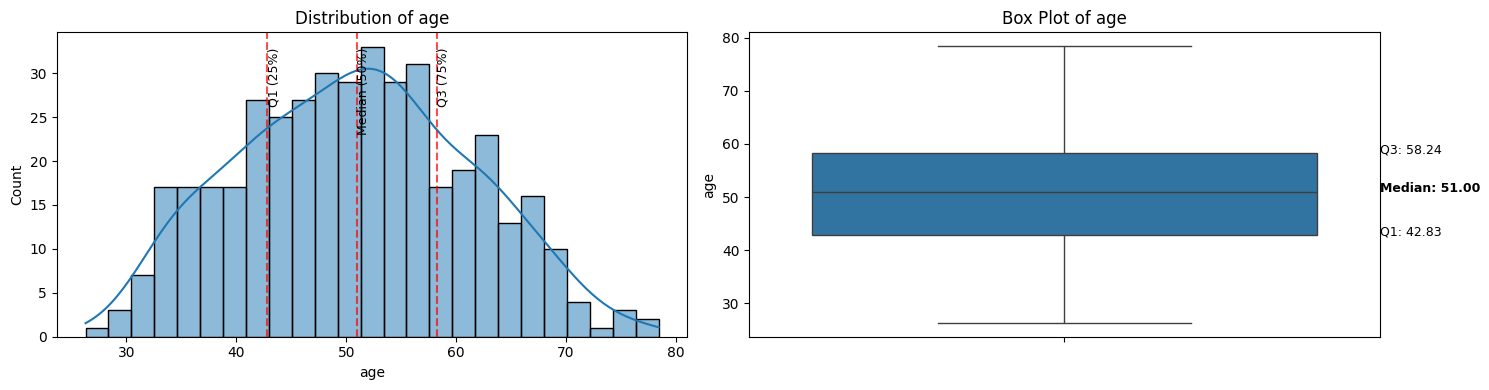

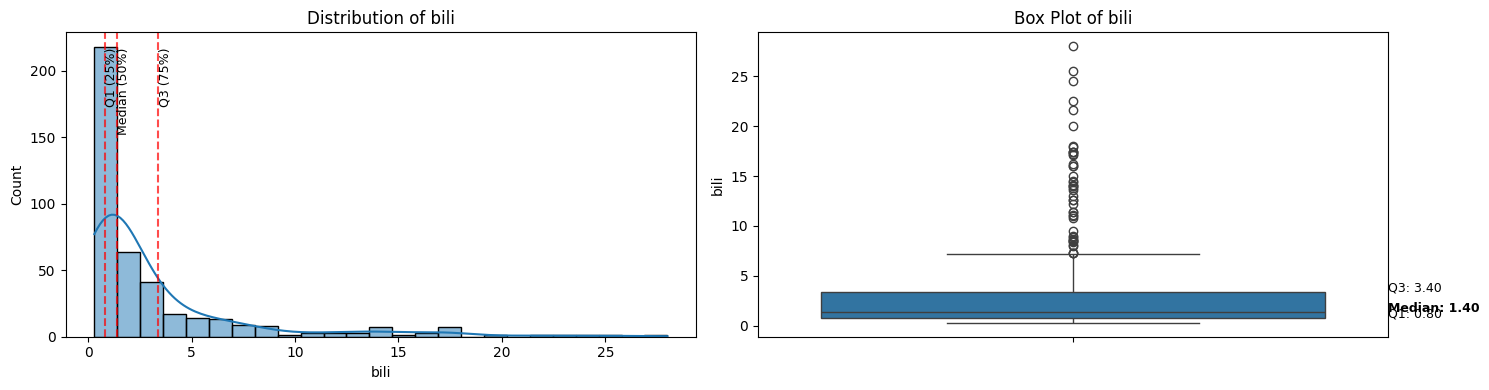

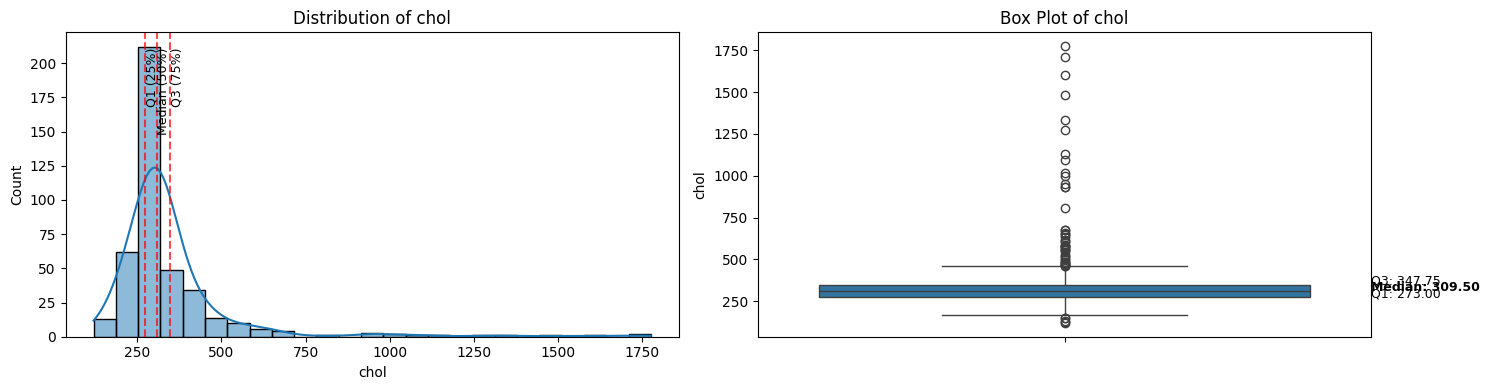

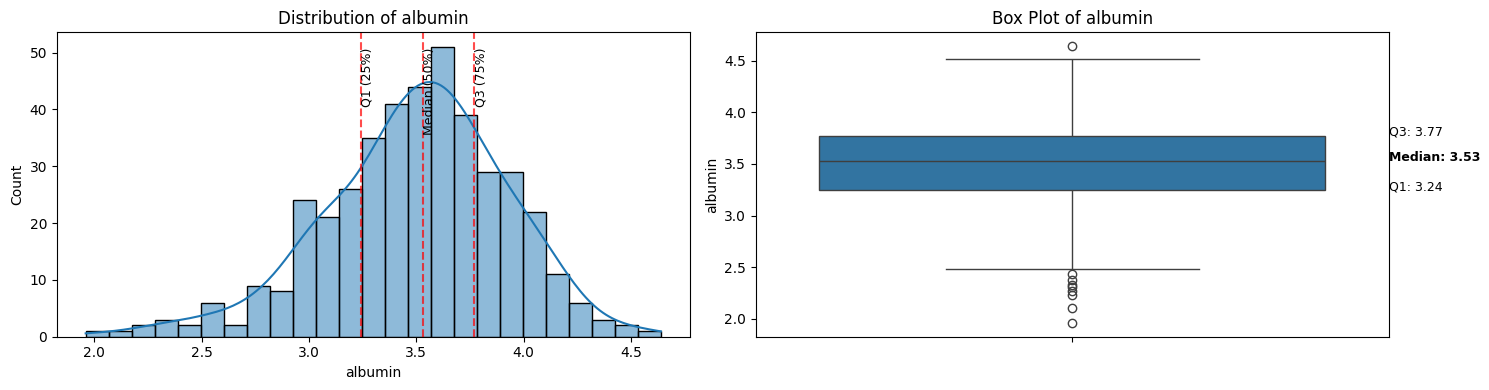

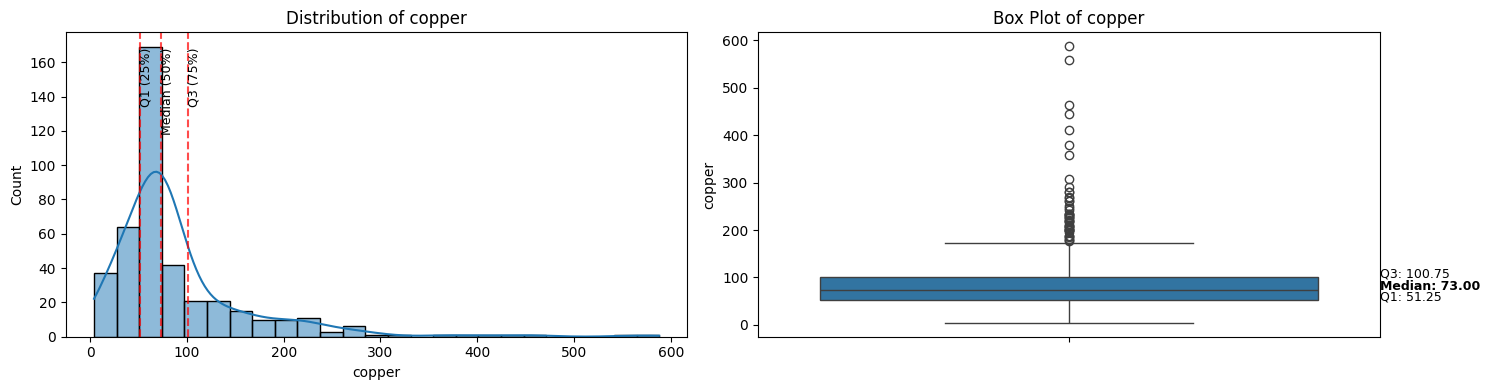

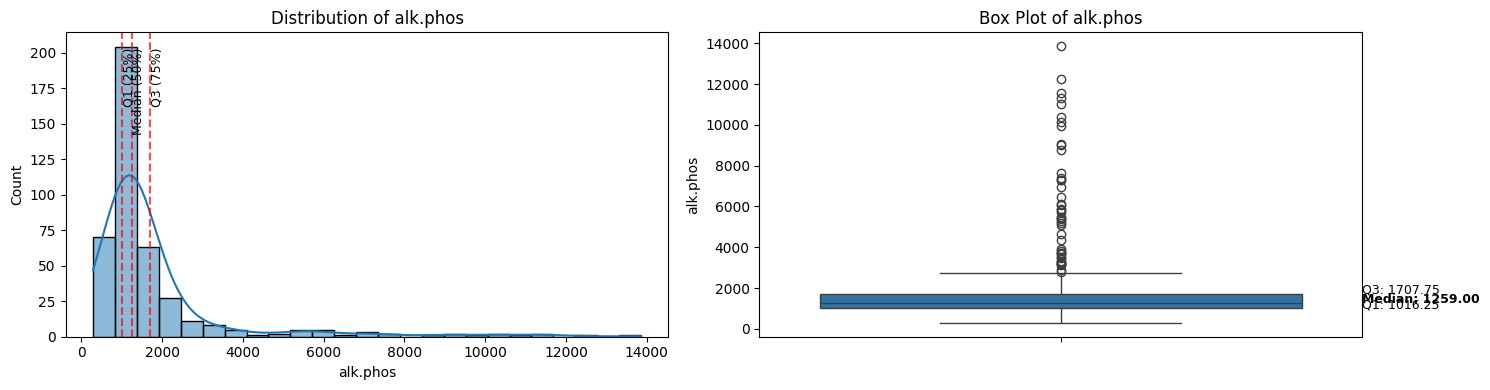

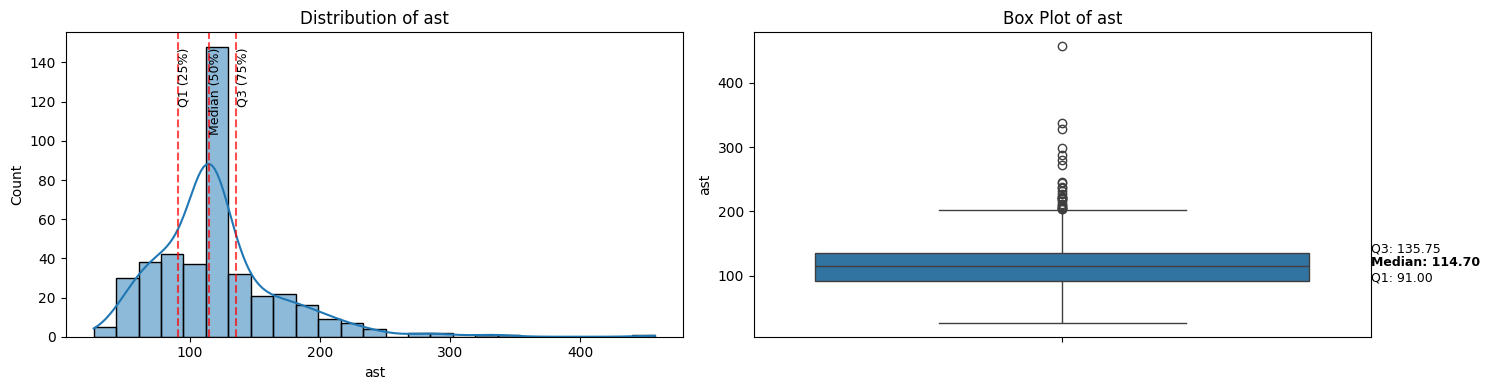

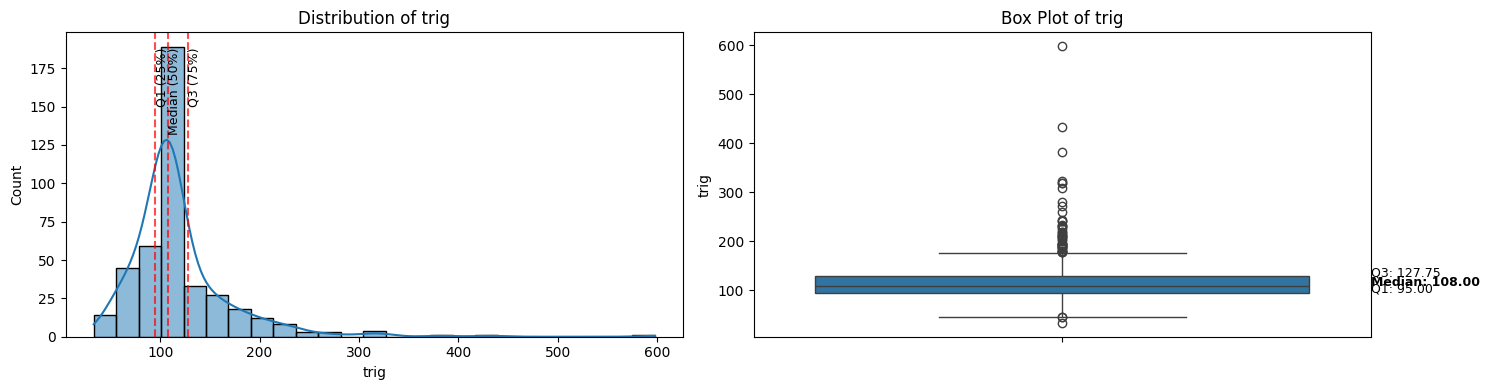

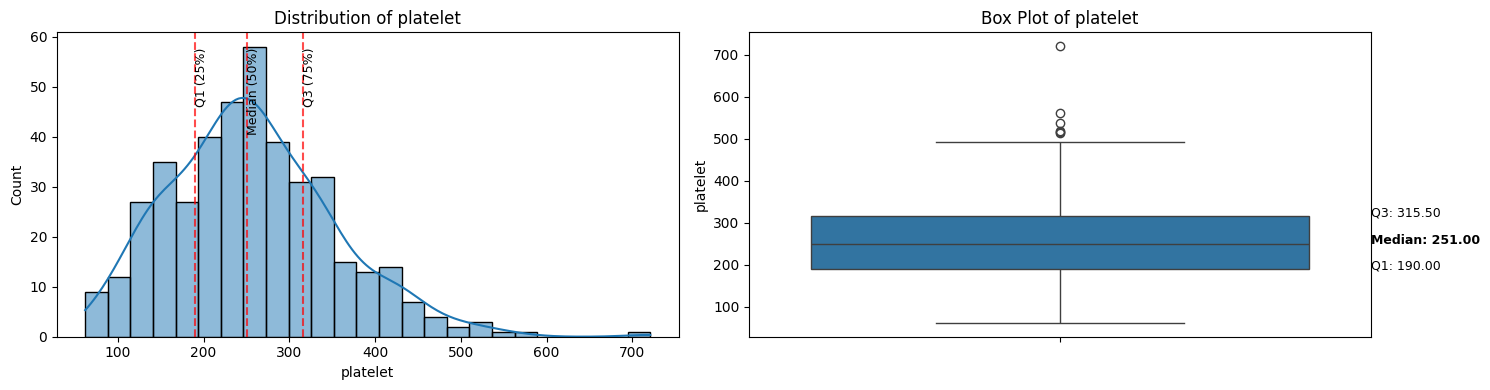

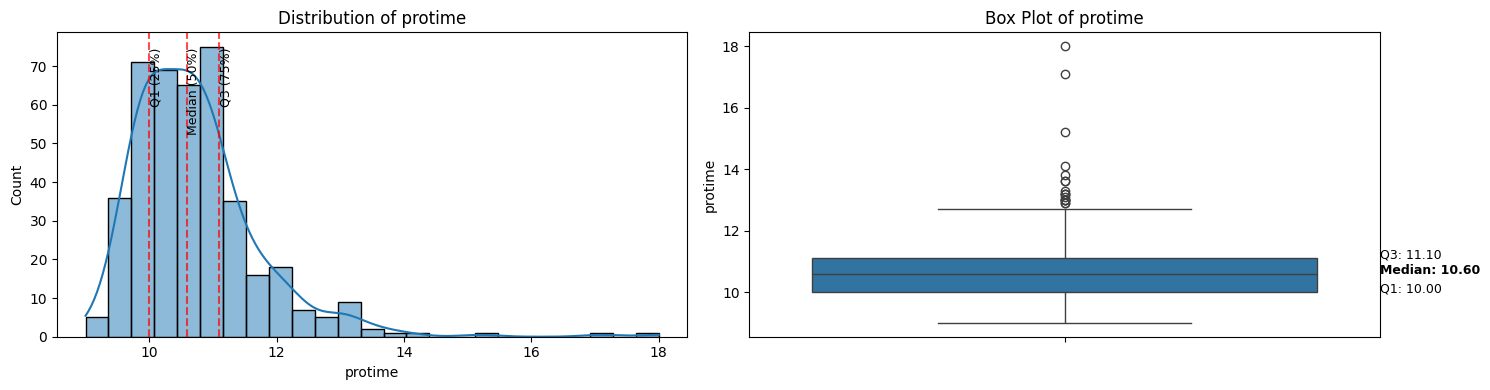

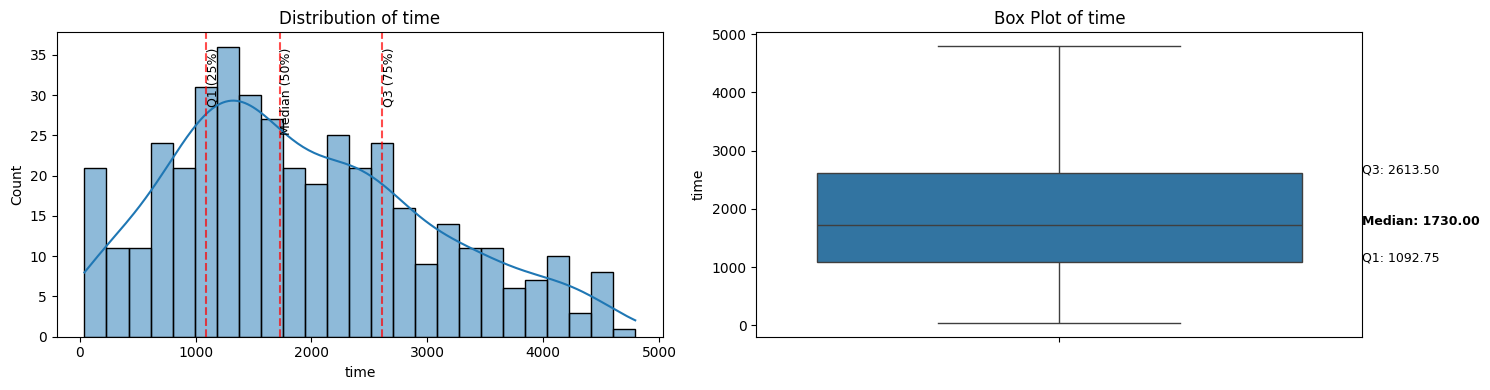

In [46]:
for col in cols_pbc_continuous:
    if col not in df_pbc.columns:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    sns.histplot(data=df_pbc, x=col, kde=True, bins=25, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    quantiles = df_pbc[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
      
    sns.boxplot(data=df_pbc, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    q1, median, q3 = df_pbc[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

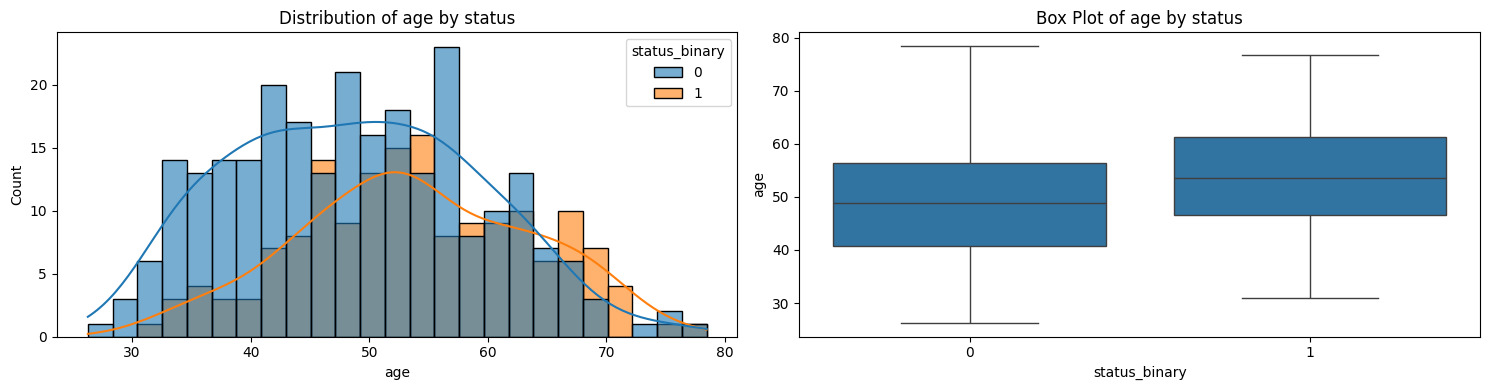

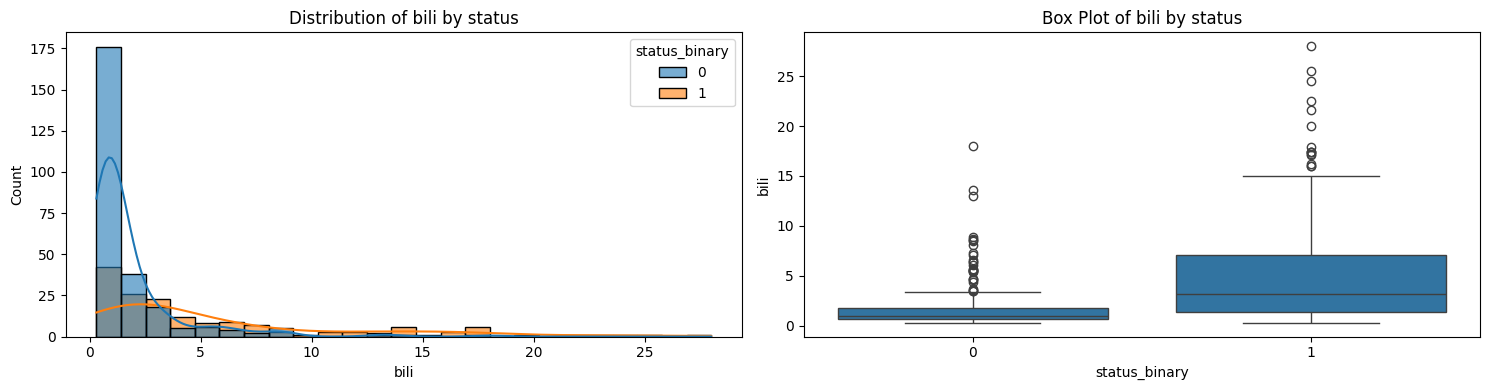

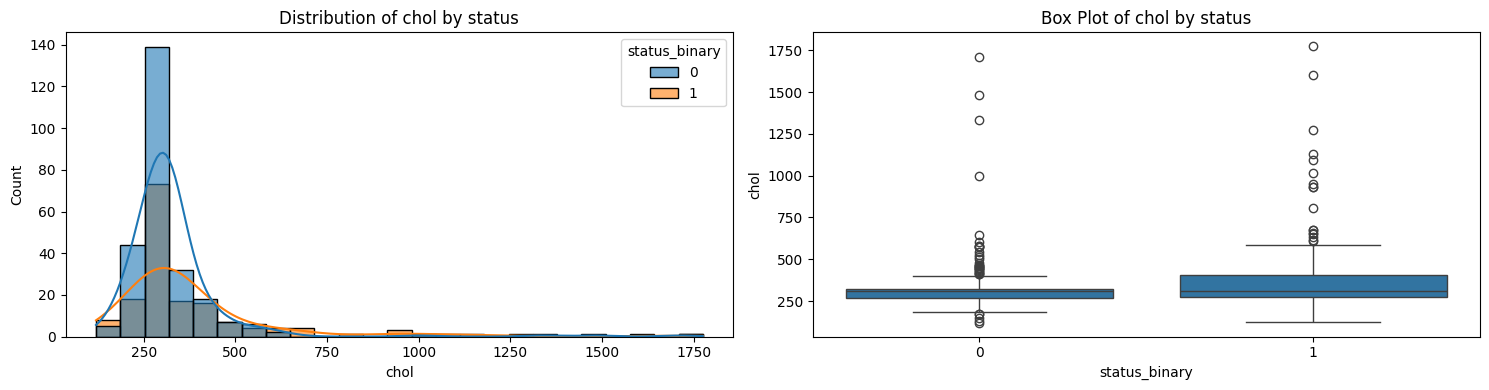

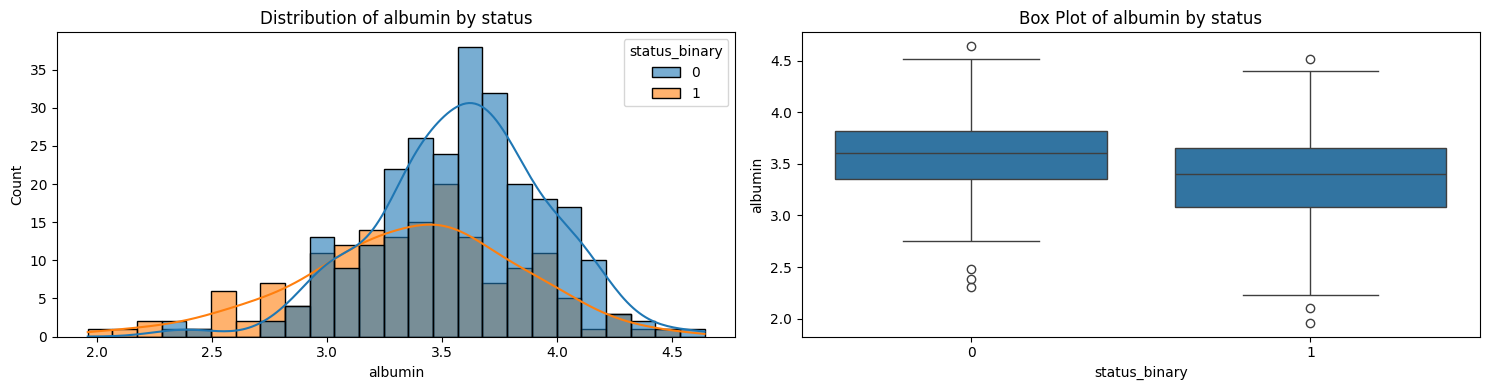

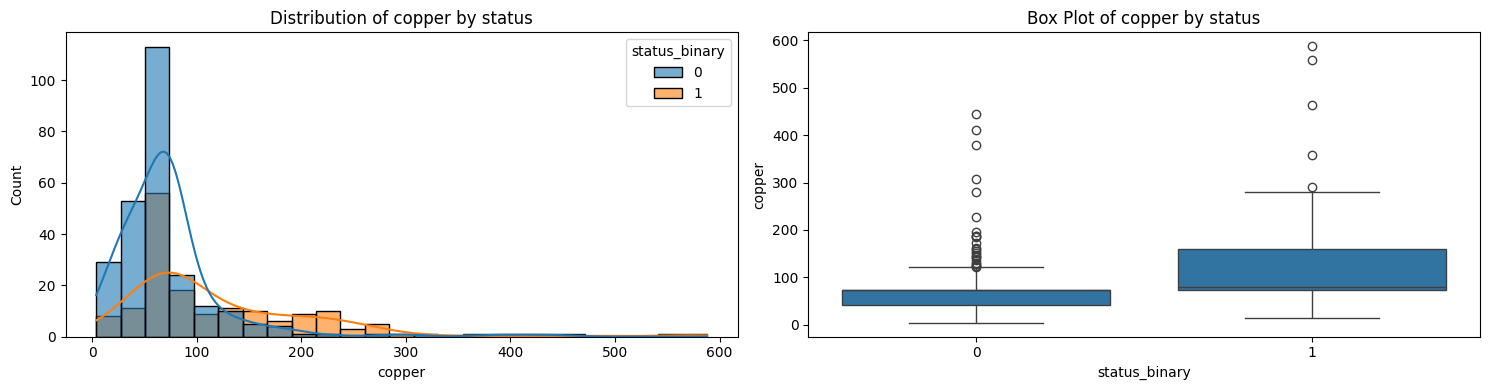

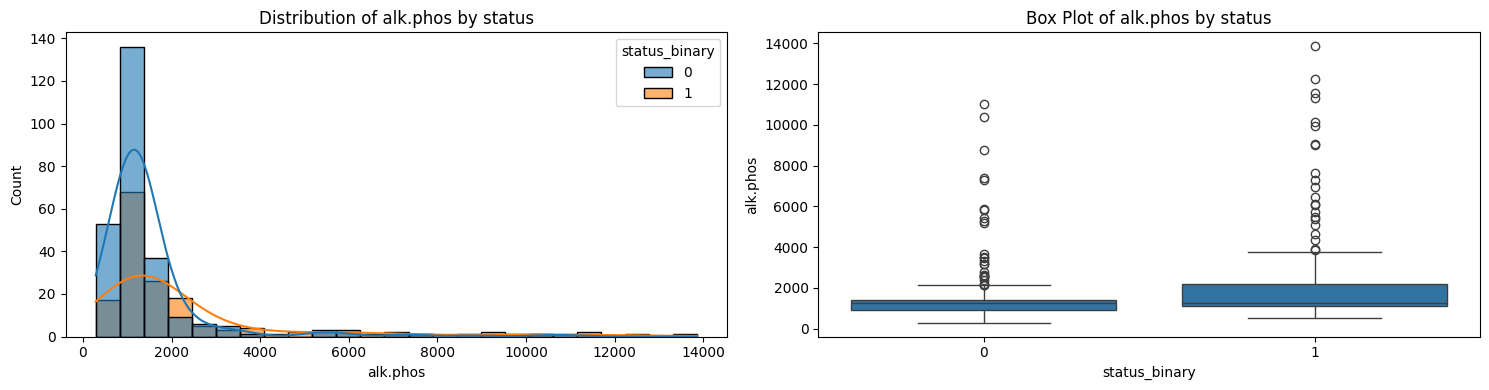

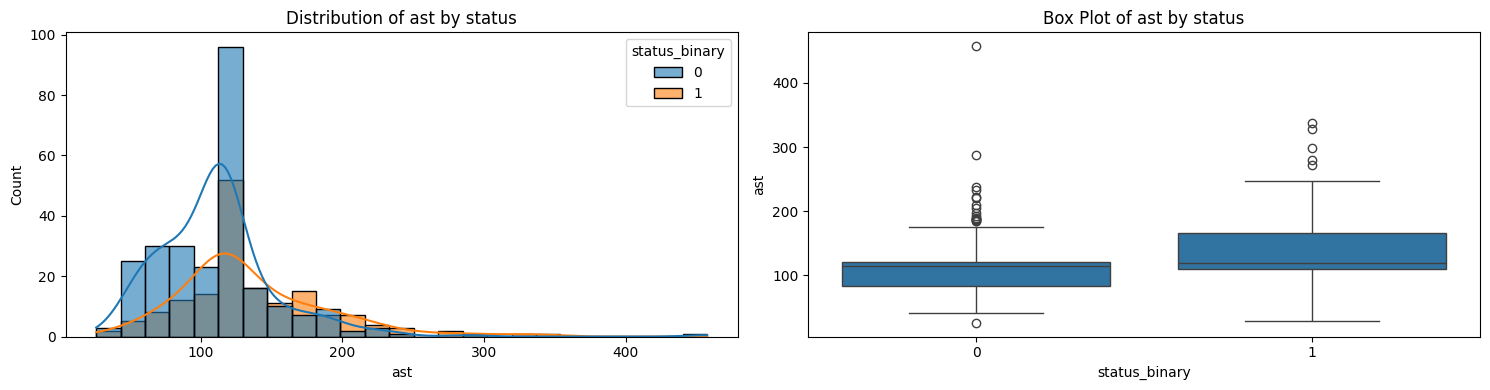

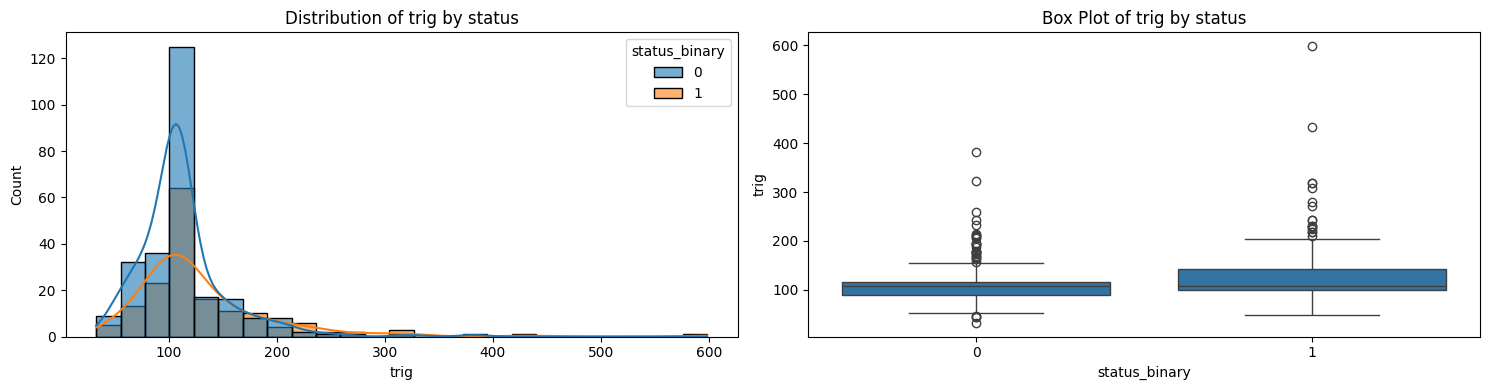

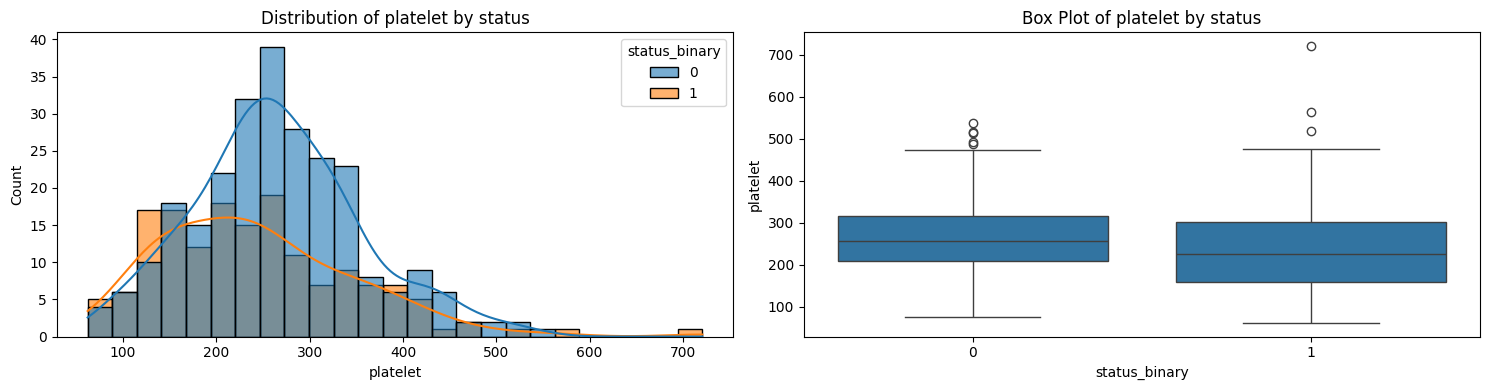

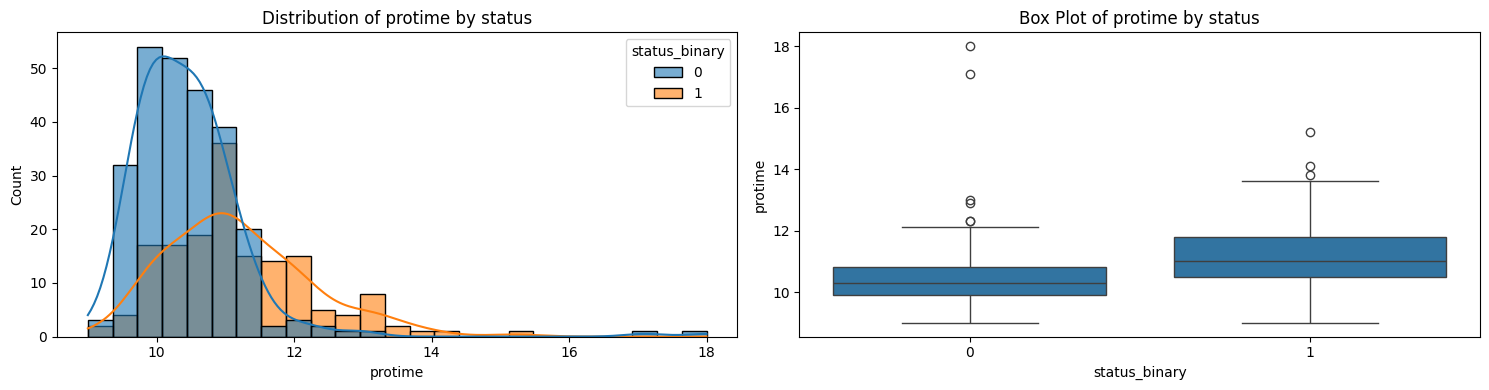

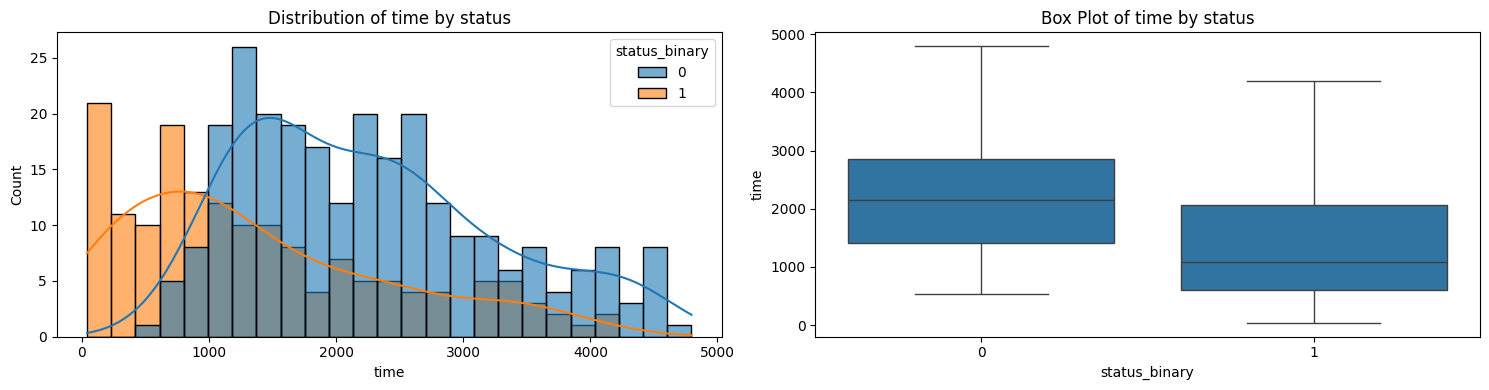

In [47]:
# Distribution by event status
for col in cols_pbc_continuous:
    if col not in df_pbc.columns:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    sns.histplot(data=df_pbc, x=col, hue='status_binary', kde=True, bins=25, alpha=0.6, ax=axes[0])
    axes[0].set_title(f"Distribution of {col} by status")
      
    sns.boxplot(data=df_pbc, x='status_binary', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by status")
   
    plt.tight_layout()
    plt.show()

#### PBC categorical variable distributions

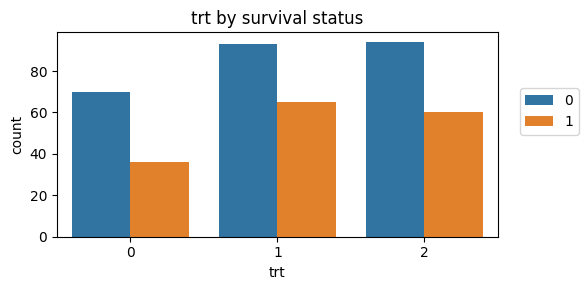

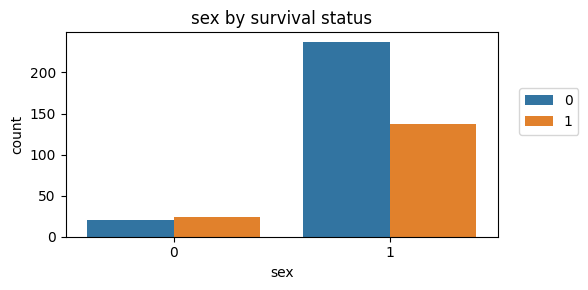

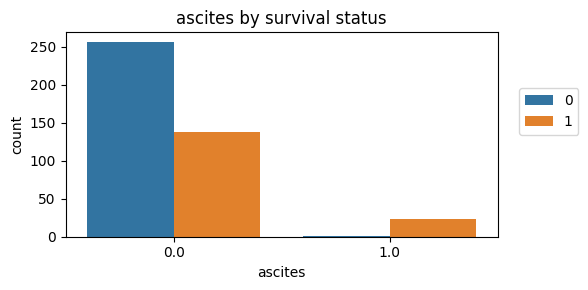

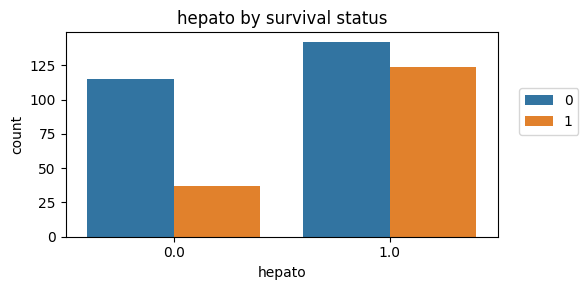

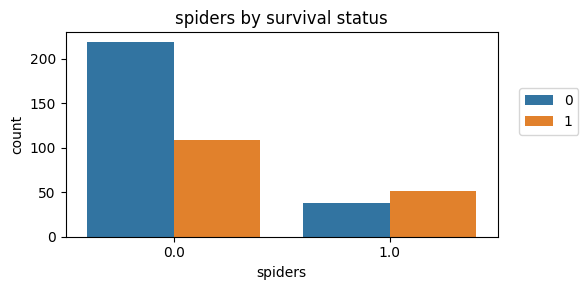

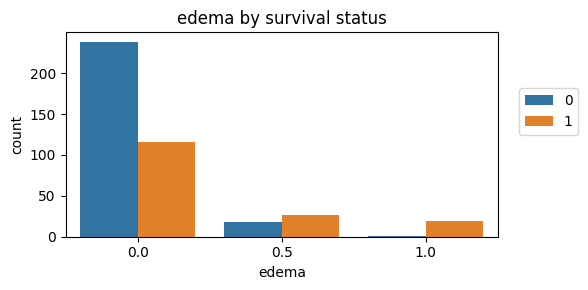

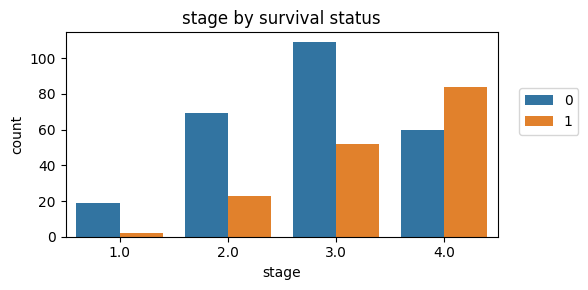

In [48]:
cols_categorical_pbc = ['trt', 'sex', 'ascites', 'hepato', 'spiders', 'edema', 'stage']

for col in cols_categorical_pbc:
    if col in df_pbc.columns:
        plt.figure(figsize=(6, 3), dpi=100) 
        sns.countplot(data=df_pbc, x=col, hue='status_binary') 
        plt.title(f"{col} by survival status")
        plt.legend(loc=(1.05, 0.5))
        plt.tight_layout()
        plt.show()

#### PBC correlation analysis

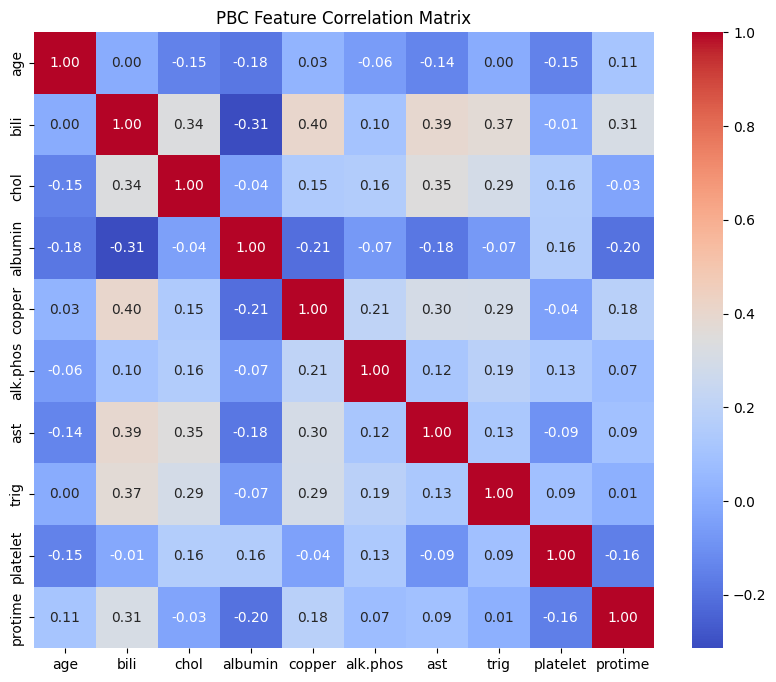

In [49]:
# Correlation of original continuous covariates (not log-transformed, not outcome)
corr_cols_pbc = [c for c in continuous_cols_pbc if c in df_pbc.columns]

plt.figure(figsize=(10, 8))
corr = df_pbc[corr_cols_pbc].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("PBC Feature Correlation Matrix")
plt.show()

#### PBC modelling

In [50]:
T = df_pbc['time']
E = df_pbc['status_binary']

survival_table_from_events(T, E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,418,418
41.0,2,2,0,0,418
43.0,1,1,0,0,416
51.0,1,1,0,0,415
71.0,1,1,0,0,414
...,...,...,...,...,...
4500.0,1,0,1,0,5
4509.0,1,0,1,0,4
4523.0,1,0,1,0,3


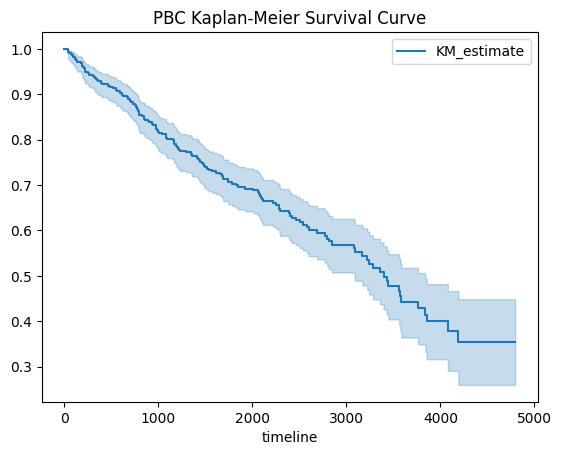

In [51]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)
kmf.plot_survival_function()
plt.title("PBC Kaplan-Meier Survival Curve")
plt.show()

In [52]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
41.0,0.995215
43.0,0.992823
51.0,0.990431
71.0,0.988038
...,...
4500.0,0.353396
4509.0,0.353396
4523.0,0.353396


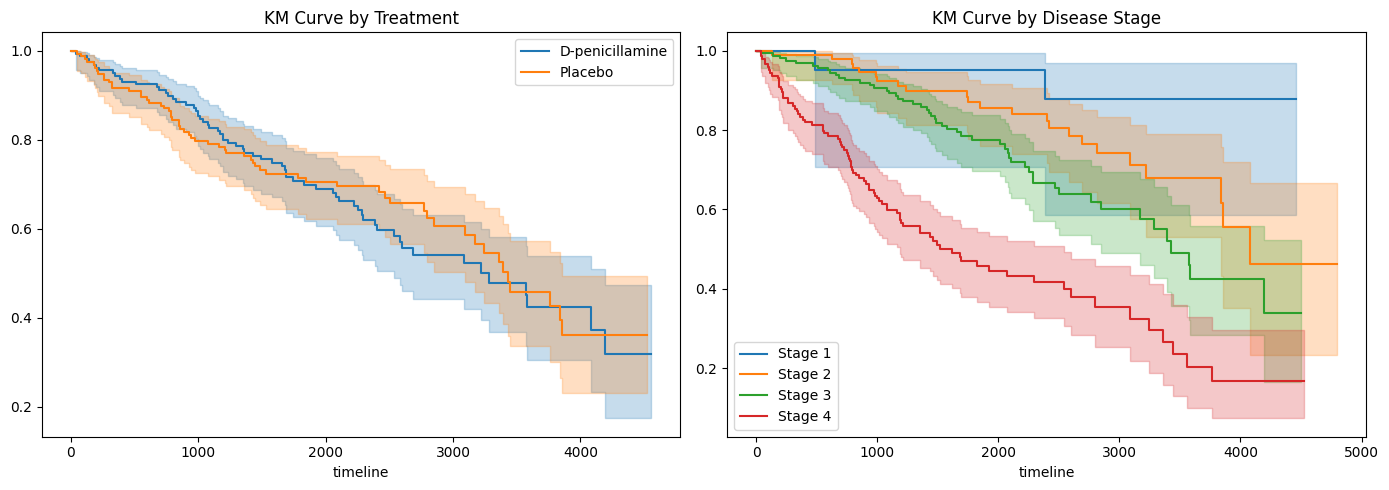

In [53]:
# KM stratified by treatment and stage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for trt_val, label in [(1, 'D-penicillamine'), (2, 'Placebo')]:
    mask = df_pbc['trt'] == trt_val
    kmf_tmp = KaplanMeierFitter()
    kmf_tmp.fit(df_pbc.loc[mask, 'time'], event_observed=df_pbc.loc[mask, 'status_binary'], label=label)
    kmf_tmp.plot_survival_function(ax=axes[0])
axes[0].set_title("KM Curve by Treatment")

for stage_val in sorted(df_pbc['stage'].dropna().unique()):
    mask = df_pbc['stage'] == stage_val
    kmf_tmp = KaplanMeierFitter()
    kmf_tmp.fit(df_pbc.loc[mask, 'time'], event_observed=df_pbc.loc[mask, 'status_binary'], label=f'Stage {int(stage_val)}')
    kmf_tmp.plot_survival_function(ax=axes[1])
axes[1].set_title("KM Curve by Disease Stage")

plt.tight_layout()
plt.show()

In [54]:
wft = WeibullAFTFitter()

# Use non-skewed covariates + log-transformed skewed variables
weibull_cols = ['age', 'albumin', 'protime', 'edema', 'stage', 'time', 'status_binary']
weibull_cols += list(skewed_cols.values())

wft.fit(df_pbc[weibull_cols], duration_col='time', event_col='status_binary')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 418 total observations, 257 right-censored observations>
             duration col = 'time'
                event col = 'status_binary'
   number of observations = 418
number of events observed = 161
           log-likelihood = -1405.87
         time fit was run = 2026-04-01 08:58:56 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                     
lambda_ age          -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
        albumin       0.40      1.50      0.14            0.13            0.68                1.13                1.98
        edema        -0.47      0.63      0.19           -0.83           -0.11                0.44                0.90
        log_alk_phos -0.00      1.00      0.08           -0.16            0.16                0.85                1.17
        log_ast      -0.25      0.78      0.17           -0.58            0.07                0.56                1.08
        log_bili     -0.62      0.54      0.09           -0.81           -0.44                0.45                0.65
        log_chol      0.00      1.00      0.16           -0.30            0.31                0.74                1.37
        log_copper   -0.19      0.82      0.09           -0.37           -0.01                0.69                0.99
        log_protime  -9.60      0.00      7.50          -24.30            5.11                0.00              165.94
        log_trig      0.13      1.14      0.15           -0.16            0.42                0.85                1.52
        protime       0.60      1.82      0.58           -0.53            1.73                0.59                5.65
        stage        -0.21      0.81      0.08           -0.37           -0.05                0.69                0.95
        Intercept    28.04  1.51e+12     12.21            4.11           51.97               60.89            3.73e+22
rho_    Intercept     0.41      1.51      0.06            0.28            0.53                1.33                1.70

                      cmp to     z      p  -log2(p)
param   covariate                                  
lambda_ age             0.00 -3.90 <0.005     13.33
        albumin         0.00  2.85 <0.005      7.82
        edema           0.00 -2.53   0.01      6.44
        log_alk_phos    0.00 -0.02   0.98      0.03
        log_ast         0.00 -1.52   0.13      2.96
        log_bili        0.00 -6.60 <0.005     34.48
        log_chol        0.00  0.03   0.98      0.03
        log_copper      0.00 -2.11   0.04      4.83
        log_protime     0.00 -1.28   0.20      2.31
        log_trig        0.00  0.86   0.39      1.37
        protime         0.00  1.04   0.30      1.74
        stage           0.00 -2.56   0.01      6.57
        Intercept       0.00  2.30   0.02      5.53
rho_    Intercept       0.00  6.45 <0.005     33.04
---
Concordance = 0.85
AIC = 2839.74
log-likelihood ratio test = 250.30 on 12 df
-log2(p) of ll-ratio test = 152.56

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

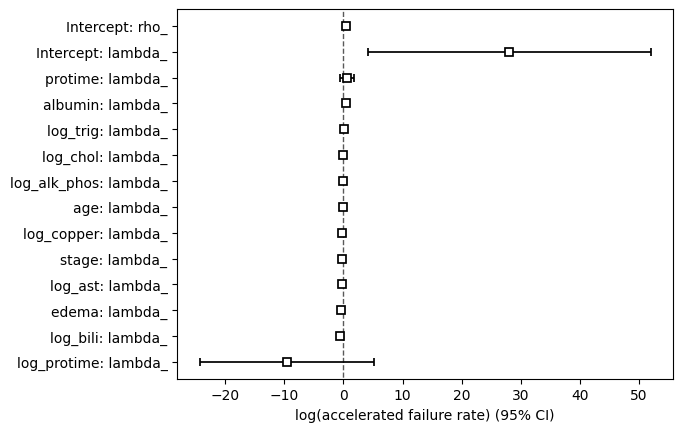

In [55]:
wft.plot()

In [56]:
# Features for Cox PH: use log-transformed versions for skewed variables
# Do NOT include both raw and log-transformed versions (multicollinearity)
# Include stage as a covariate (important prognostic variable)
# edema will be used as strata (often violates proportional hazards)
features_pbc = ['age', 'albumin', 'protime', 'stage', 'edema', 'time', 'status_binary']
features_pbc += list(skewed_cols.values())

print("Cox PH features:", features_pbc)

Cox PH features: ['age', 'albumin', 'protime', 'stage', 'edema', 'time', 'status_binary', 'log_bili', 'log_chol', 'log_copper', 'log_alk_phos', 'log_ast', 'log_trig', 'log_protime']


In [57]:
df_pbc[features_pbc].to_csv(r'./data/preprocess-data/preprocess_pbc.csv')

In [58]:
cph = CoxPHFitter()
cph.fit(df_pbc[features_pbc], duration_col='time', event_col='status_binary', 
        strata=['edema'])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 418 total observations, 257 right-censored observations>
             duration col = 'time'
                event col = 'status_binary'
                   strata = edema
      baseline estimation = breslow
   number of observations = 418
number of events observed = 161
   partial log-likelihood = -639.44
         time fit was run = 2026-04-01 08:58:57 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
age           0.03      1.04      0.01            0.02            0.05                1.02                1.05
albumin      -0.66      0.52      0.22           -1.08           -0.23                0.34                0.79
protime      -0.92      0.40      0.84           -2.57            0.73                0.08                2.07
stage         0.32      1.38      0.12            0.08            0.57                1.09                1.76
log_bili      0.97      2.63      0.15            0.67            1.26                1.96                3.53
log_chol      0.09      1.09      0.24           -0.38            0.55                0.69                1.74
log_copper    0.29      1.34      0.14            0.01            0.57                1.01                1.77
log_alk_phos -0.05      0.96      0.13           -0.30            0.21                0.74                1.23
log_ast       0.36      1.43      0.25           -0.14            0.85                0.87                2.33
log_trig     -0.31      0.73      0.23           -0.77            0.14                0.46                1.15
log_protime  14.70  2.42e+06     11.00           -6.87           36.27                0.00            5.62e+15

              cmp to     z      p  -log2(p)
covariate                                  
age             0.00  4.00 <0.005     13.94
albumin         0.00 -3.02 <0.005      8.61
protime         0.00 -1.09   0.27      1.87
stage           0.00  2.64   0.01      6.93
log_bili        0.00  6.47 <0.005     33.26
log_chol        0.00  0.37   0.71      0.49
log_copper      0.00  2.04   0.04      4.60
log_alk_phos    0.00 -0.35   0.72      0.47
log_ast         0.00  1.42   0.16      2.68
log_trig        0.00 -1.35   0.18      2.50
log_protime     0.00  1.34   0.18      2.46
---
Concordance = 0.83
Partial AIC = 1300.89
log-likelihood ratio test = 180.01 on 11 df
-log2(p) of ll-ratio test = 106.27


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 418 total observations, 257 right-censored observations>
         test_name = proportional_hazard_test

---
                   test_statistic    p  -log2(p)
age          km              1.77 0.18      2.44
             rank            6.28 0.01      6.36
albumin      km              0.48 0.49      1.03
             rank            0.84 0.36      1.48
log_alk_phos km              0.71 0.40      1.33
             rank            0.83 0.36      1.47
log_ast      km              1.33 0.25      2.01
             rank            0.02 0.89      0.17
log_bili     km              0.01 0.92      0.11
             rank            0.60 0.44      1.18
log_chol     km              1.70 0.19      2.38
             rank            0.01 0.93      0.10
log_copper   km              1.46 0.23      2.14
             rank            1.01 0.32      1.67
log_protime  km              0.43 0.51      0.97
             rank            0.15 0.70      0.52
log_trig     km              1.61 0.20      2.29
             rank            0.21 0.64      0.63
protime      km              0.73 0.39      1.35
             rank            0.07 0.80      0.33
stage        km              0.74 0.39      1.36
             rank            1.35 0.24      2.03



1. Variable 'age' failed the non-proportional test: p-value is 0.0122.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment..

[[<Axes: xlabel='rank-transformed time\n(p=0.0122)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1837)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3589)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4904)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7962)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3920)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2444)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3909)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4404)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9248)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9314)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1918)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3152)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2275)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3613)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3984)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8879)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2484)'>],
 [<Axes: xlabel='rank-transformed tim

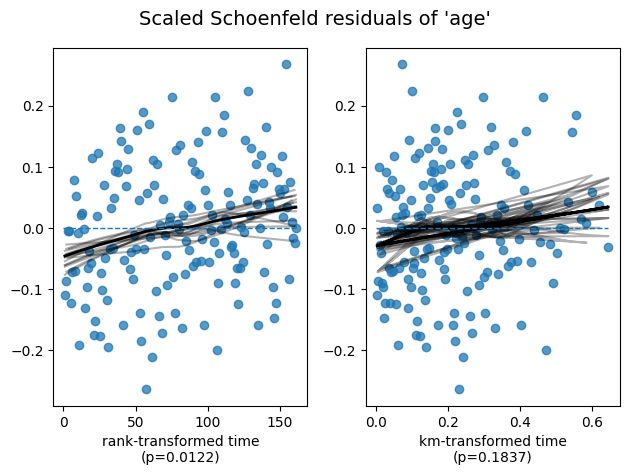

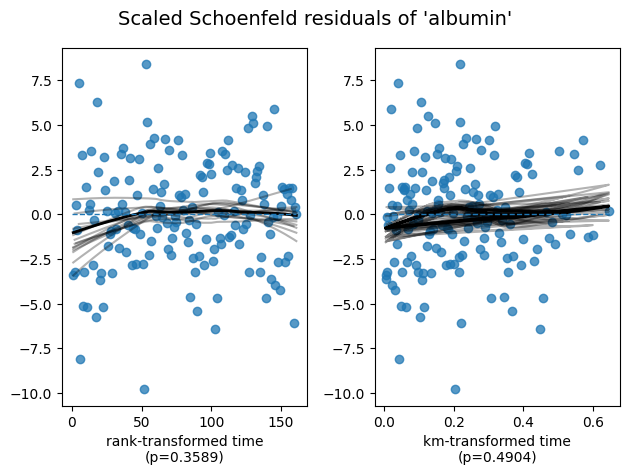

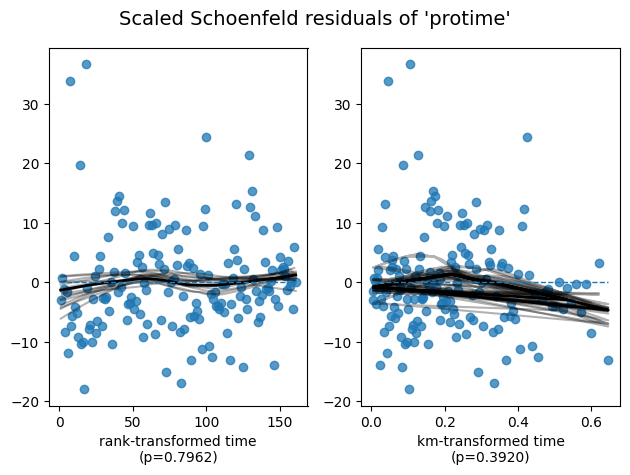

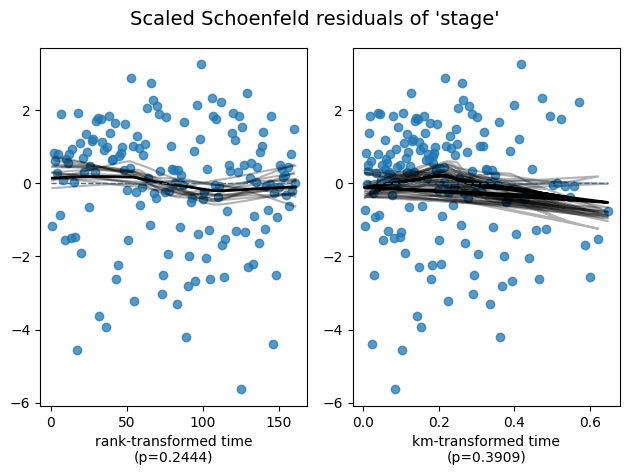

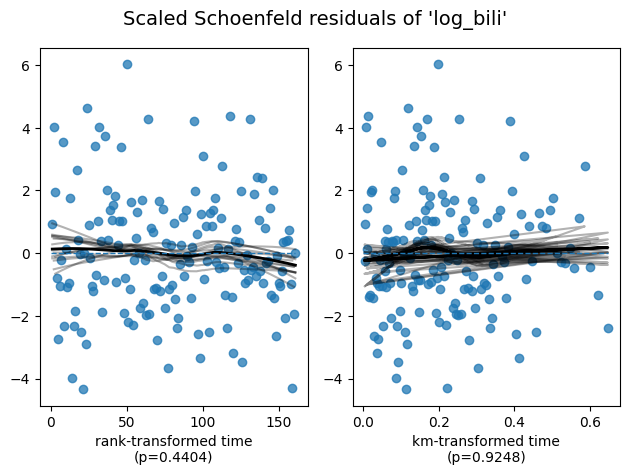

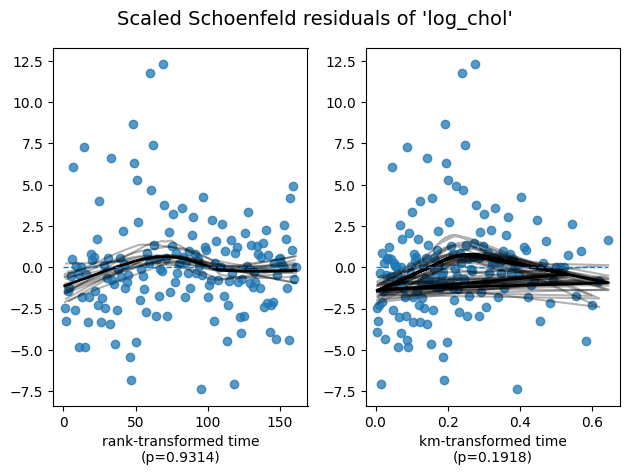

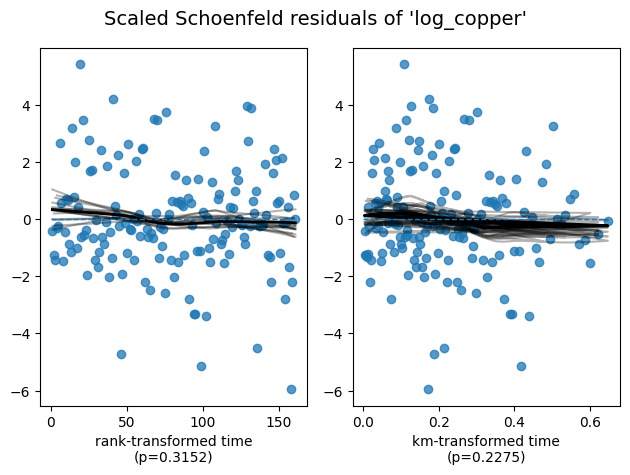

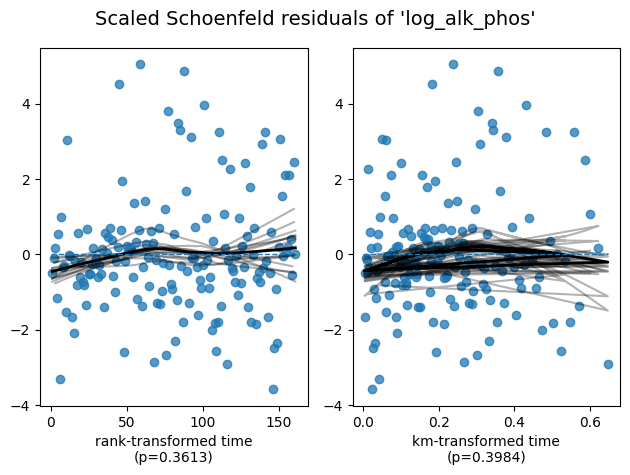

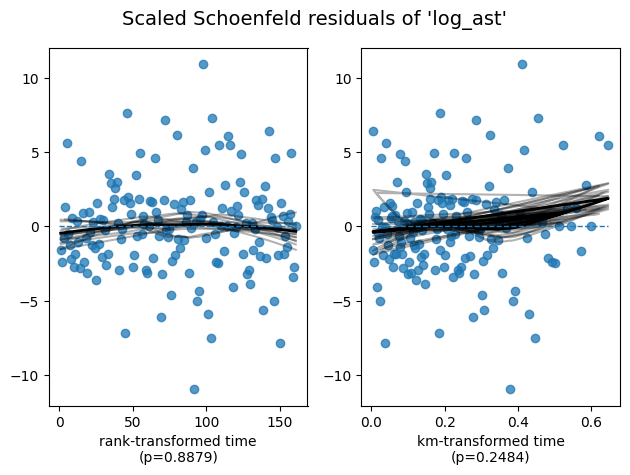

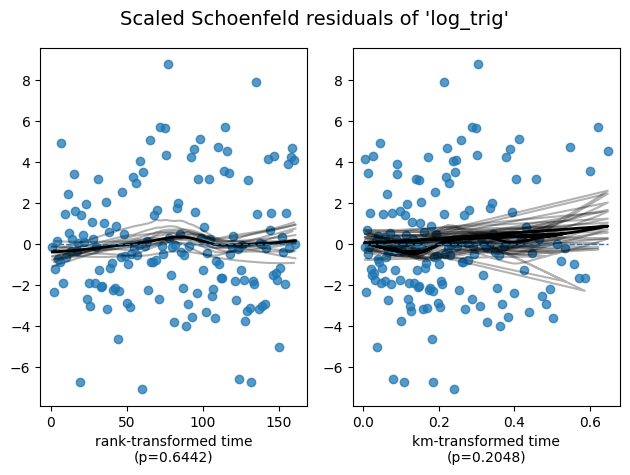

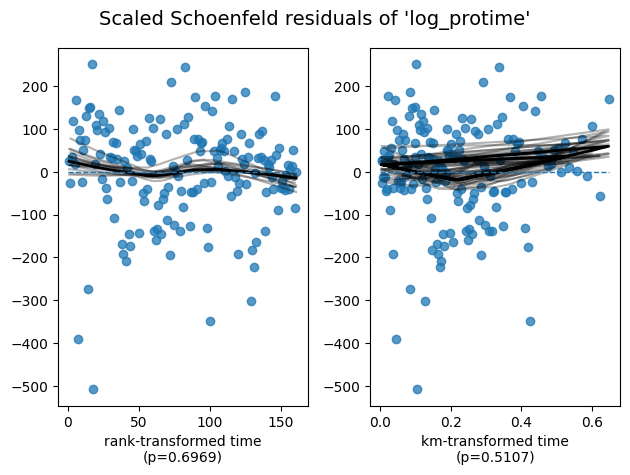

In [59]:
cph.check_assumptions(df_pbc[features_pbc], show_plots=True, p_value_threshold=0.05)

In [60]:
scores = k_fold_cross_validation(
    cph, df_pbc[features_pbc], duration_col='time', event_col='status_binary', k=5,
    scoring_method='concordance_index'
)

print("Average C-index:", np.mean(scores))

c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index i

Average C-index: 0.8349312590212721


c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


In [61]:
pred = cph.predict_partial_hazard(df_pbc)
c_index_pbc = concordance_index(df_pbc["time"], -pred, df_pbc["status_binary"])
print("CoxPH C-index:", c_index_pbc)

CoxPH C-index: 0.8422305649665781


In [62]:
ibs_pbc = compute_ibs(
    cph=cph,
    df=df_pbc,
    duration_col="time",
    event_col="status_binary"
)

print("CoxPH IBS:", ibs_pbc)

CoxPH IBS: 0.2692016624880356


In [63]:
print("AIC:", cph.AIC_partial_)

AIC: 990.6194618397835


In [64]:
log_likelihood = cph.log_likelihood_
k = len(cph.params_)
n = cph._n_examples

bic = -2 * log_likelihood + k * np.log(n)

print("BIC:", bic)

BIC: 1032.5748976898592


### Simulated Data

In [65]:
df_sd.shape

(200, 5)

In [66]:
df_sd.head(10)

,Age,Treatment,Sex,Time,Event
0,54.967142,1,1,0.075964,1
1,48.617357,1,0,0.196966,1
2,56.476885,1,0,0.226271,1
3,65.230299,1,1,0.074202,1
4,47.658466,0,0,0.190551,1
5,47.658630,0,1,0.253558,1
6,65.792128,1,0,0.095786,1
7,57.674347,1,1,0.631463,0
8,45.305256,1,0,0.117190,1
9,55.425600,1,1,0.514171,1


In [67]:
df_sd.isna().sum()

Age          0
Treatment    0
Sex          0
Time         0
Event        0
dtype: int64

In [68]:
df_sd.describe()

,Age,Treatment,Sex,Time,Event
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,49.592290,0.520000,0.500000,0.624313,0.705000
std,9.310039,0.500854,0.501255,0.732027,0.457187
min,23.802549,0.000000,0.000000,0.004059,0.000000
25%,42.948723,0.000000,0.000000,0.151343,0.000000
50%,49.958081,1.000000,0.500000,0.398990,1.000000
75%,55.008525,1.000000,1.000000,0.832125,1.000000
max,77.201692,1.000000,1.000000,4.463726,1.000000


In [69]:
print(df_sd["Event"].value_counts())

print("\nIn Percentage:")
print(df_sd['Event'].value_counts(normalize=True))

Event
1    141
0     59
Name: count, dtype: int64

In Percentage:
Event
1    0.705
0    0.295
Name: proportion, dtype: float64


In [70]:
event_rate = df_sd["Event"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")

Event rate: 0.70
Censoring rate: 0.30


#### Simulated data skewness check

In [71]:
# Check skewness of the only continuous covariate
continuous_cols_sd = ['Age', 'Time']

print("Skewness of simulated data continuous variables:")
print("-" * 45)
for col in continuous_cols_sd:
    skew = df_sd[col].skew()
    print(f"  {col:>6s}  skew={skew:+.2f}  min={df_sd[col].min():.2f}")

# Age is approximately normal (|skew| < 1) → no log transformation needed
# Time is the outcome variable, not a covariate → no transformation
print("\nNo log transformations needed for this dataset.")

Skewness of simulated data continuous variables:
---------------------------------------------
     Age  skew=+0.13  min=23.80
    Time  skew=+2.58  min=0.00

No log transformations needed for this dataset.


#### Simulated data distributions

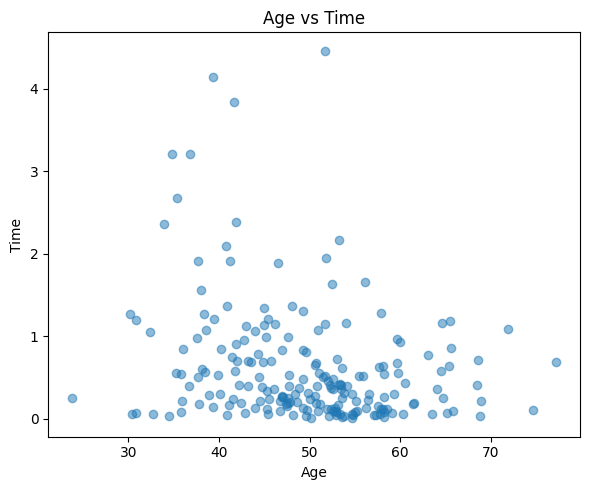

In [72]:
cols_sd = ['Age', 'Time']

pairs = list(itertools.combinations(cols_sd, 2))
n = len(pairs)

fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_sd[x], df_sd[y], alpha=0.5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

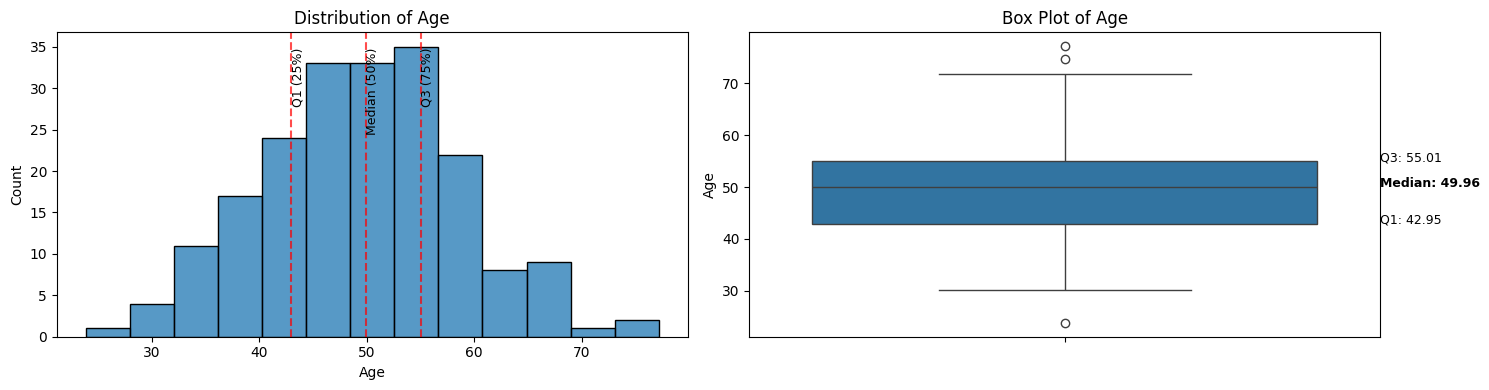

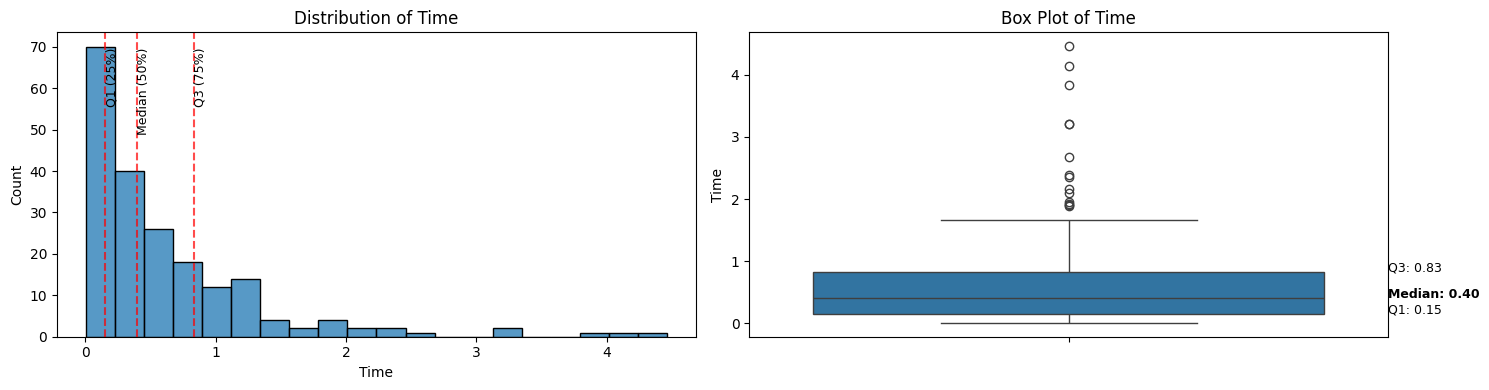

In [73]:
for col in cols_sd:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    sns.histplot(data=df_sd, x=col, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    quantiles = df_sd[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
    
    sns.boxplot(data=df_sd, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    q1, median, q3 = df_sd[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

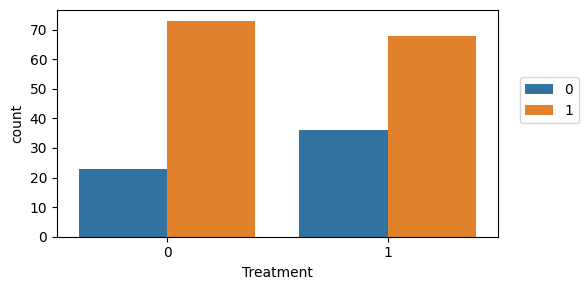

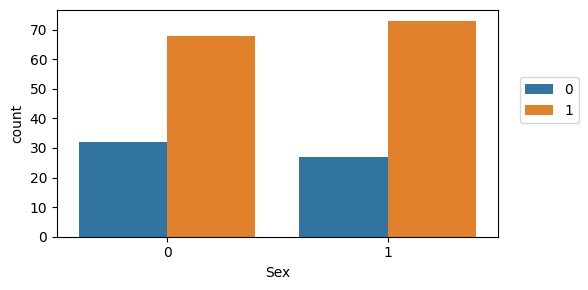

In [74]:
cols_qualitative_sd = ['Treatment', 'Sex']

for col in cols_qualitative_sd:
    plt.figure(figsize=(6, 3), dpi=100)
    sns.countplot(data=df_sd, x=col, hue='Event')
    plt.legend(loc=(1.05, 0.5))
    plt.tight_layout()
    plt.show()

In [75]:
df_sd[cols_sd].corr().abs()

,Age,Time
Age,1.000000,0.250167
Time,0.250167,1.000000


#### Simulated data modelling

In [76]:
T = df_sd['Time']
E = df_sd['Event']

survival_table_from_events(T, E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.000000,0,0,0,200,200
0.004059,1,1,0,0,200
0.010749,1,1,0,0,199
0.022113,1,0,1,0,198
0.026174,1,0,1,0,197
...,...,...,...,...,...
3.205239,1,1,0,0,5
3.206745,1,0,1,0,4
3.845280,1,1,0,0,3


<Axes: xlabel='timeline'>

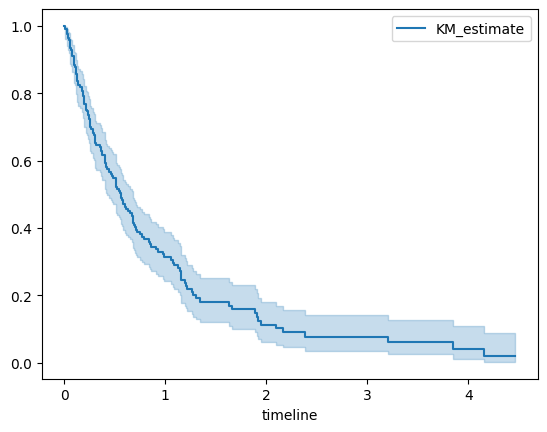

In [77]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)
kmf.plot_survival_function()

In [78]:
kmf.survival_function_

,KM_estimate
timeline,
0.000000,1.000000
0.004059,0.995000
0.010749,0.990000
0.022113,0.990000
0.026174,0.990000
...,...
3.205239,0.062044
3.206745,0.062044
3.845280,0.041362


In [79]:
wft = WeibullAFTFitter()
wft.fit(df_sd, duration_col='Time', event_col='Event')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
   number of observations = 200
number of events observed = 141
           log-likelihood = -105.22
         time fit was run = 2026-04-01 08:59:51 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ Age       -0.04      0.96      0.01           -0.06           -0.03                0.94                0.97
        Sex       -0.25      0.78      0.17           -0.58            0.07                0.56                1.07
        Treatment  0.50      1.65      0.16            0.18            0.81                1.20                2.25
        Intercept  1.92      6.80      0.46            1.02            2.81                2.77               16.69
rho_    Intercept  0.05      1.05      0.06           -0.08            0.18                0.93                1.19

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ Age          0.00 -5.46 <0.005     24.35
        Sex          0.00 -1.53   0.13      2.98
        Treatment    0.00  3.10 <0.005      9.02
        Intercept    0.00  4.18 <0.005     15.09
rho_    Intercept    0.00  0.76   0.45      1.17
---
Concordance = 0.64
AIC = 220.44
log-likelihood ratio test = 36.39 on 3 df
-log2(p) of ll-ratio test = 23.95

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

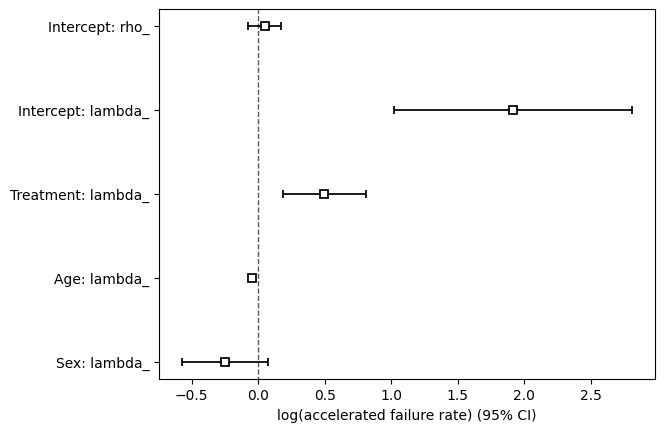

In [80]:
wft.plot()

In [81]:
df_sd.to_csv(r'./data/preprocess-data/preprocess_simulated_data.csv')

In [82]:
cph = CoxPHFitter()
cph.fit(df_sd, duration_col='Time', event_col='Event', strata=['Treatment', 'Sex'])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                   strata = ['Treatment', 'Sex']
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -405.34
         time fit was run = 2026-04-01 08:59:52 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Age        0.04      1.05      0.01            0.03            0.06                1.03                1.06

           cmp to    z      p  -log2(p)
covariate                              
Age          0.00 4.98 <0.005     20.56
---
Concordance = 0.65
Partial AIC = 812.67
log-likelihood ratio test = 23.95 on 1 df
-log2(p) of ll-ratio test = 19.95


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.4300)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9466)'>]]

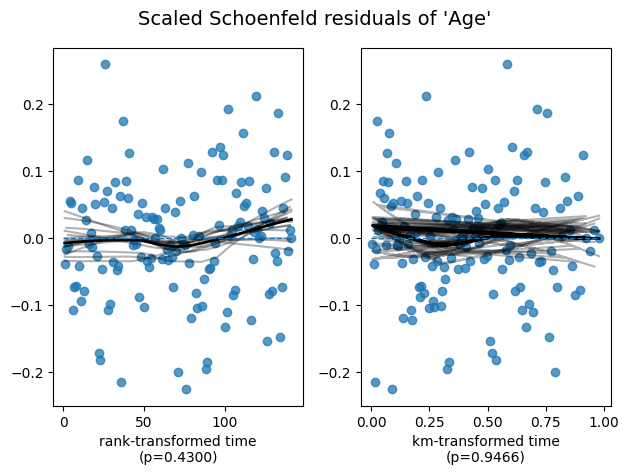

In [83]:
cph.check_assumptions(df_sd, show_plots=True, p_value_threshold=0.05)

In [84]:
scores = k_fold_cross_validation(
    cph, df_sd, duration_col='Time', event_col='Event', k=5,
    scoring_method='concordance_index'
)

print("Average C-index:", np.mean(scores))

c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index i

Average C-index: 0.6387931062156392


c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


In [85]:
pred = cph.predict_partial_hazard(df_sd)
c_index_sd = concordance_index(df_sd["Time"], -pred, df_sd["Event"])
print("CoxPH C-index:", c_index_sd)

CoxPH C-index: 0.6412972972972973


In [86]:
ibs_sd = compute_ibs(
    cph=cph,
    df=df_sd,
    duration_col="Time",
    event_col="Event"
)

print("CoxPH IBS:", ibs_sd)

CoxPH IBS: 0.12852545072695712


In [87]:
print("AIC:", cph.AIC_partial_)

AIC: 586.7329127542519


In [88]:
log_likelihood = cph.log_likelihood_
k = len(cph.params_)
n = cph._n_examples

bic = -2 * log_likelihood + k * np.log(n)

print("BIC:", bic)

BIC: 589.8080865694857
